<a href="https://colab.research.google.com/github/Lunaartur/tech-challenge-olist/blob/main/notebooks/tech_challenge.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

# Conjunto de Dados Público do E-commerce Brasileiro Olist

Este é um conjunto de dados público de e-commerce brasileiro com pedidos realizados na Loja Olist. O conjunto de dados contém informações de 100 mil pedidos feitos entre 2016 e 2018 em diversos marketplaces no Brasil. Seus recursos permitem visualizar um pedido sob múltiplas perspectivas: desde o status do pedido, preço, pagamento e desempenho do frete até a localização do cliente, atributos do produto e, finalmente, avaliações escritas pelos clientes. Também lançamos um conjunto de dados de geolocalização que relaciona CEPs brasileiros a coordenadas de latitude e longitude.

Estes são dados comerciais reais, foram anonimizados e as referências às empresas e parceiros no texto das avaliações foram substituídas pelos nomes das grandes casas de Game of Thrones.

## Contexto

Este conjunto de dados foi gentilmente cedido pela Olist, a maior loja de departamentos em marketplaces brasileiros. A Olist conecta pequenas empresas de todo o Brasil a canais de forma descomplicada e com um único contrato. Esses comerciantes podem vender seus produtos através da Loja Olist e enviá-los diretamente aos clientes utilizando os parceiros logísticos da Olist. Saiba mais em nosso site: www.olist.com

Após um cliente comprar um produto na Loja Olist, o vendedor é notificado para processar o pedido. Assim que o cliente recebe o produto, ou quando a data estimada de entrega se aproxima, ele recebe uma pesquisa de satisfação por e-mail, onde pode deixar um comentário sobre a experiência de compra.

**Atenção**
Um pedido pode conter vários itens.
Cada item pode ser processado por um vendedor diferente.

### Carregando e analisando os dados

In [ ]:
# importando as bibliotecas

import pandas as pd
import numpy as np
import seaborn as sns
import matplotlib.pyplot as plt
import plotly.express as px

* olist_customers_dataset.csv: Informações do cliente (cidade, estado e prefixo do CEP). Possui o customer_unique_id (identificador único do usuário) e customer_id (chave que muda a cada pedido).
* olist_orders_dataset.csv: Contém o status do pedido (delivered, shipped, etc.) e os carimbos de data/hora (compra, aprovação, entrega).
* olist_order_items_dataset.csv: Itens de cada pedido, associando o preço do produto, o valor do frete, o vendedor e o produto.
* olist_products_dataset.csv: Atributos do produto (categoria, peso, dimensões).
* olist_payments_dataset.csv: Opções de pagamento (cartão de crédito, boleto, voucher, cartão de débito) e número de parcelas.
* olist_reviews_dataset.csv: Avaliações dos clientes (notas de 1 a 5 e comentários textuais).
* olist_sellers_dataset.csv: Dados dos vendedores (cidade e estado).
* olist_geolocation_dataset.csv: Coordenadas de latitude e longitude associadas aos CEPs brasileiros.

In [ ]:
# carregando os datasets

customers = pd.read_csv('/content/olist_customers_dataset.csv')
geolocation = pd.read_csv('/content/olist_geolocation_dataset.csv')
order_items = pd.read_csv('/content/olist_order_items_dataset.csv')
order_payments = pd.read_csv('/content/olist_order_payments_dataset.csv')
order_reviews = pd.read_csv('/content/olist_order_reviews_dataset.csv')
orders_dataset = pd.read_csv('/content/olist_orders_dataset.csv')
products = pd.read_csv('/content/olist_products_dataset.csv')
sellers = pd.read_csv('/content/olist_sellers_dataset.csv')
product_category_name_translation = pd.read_csv('/content/product_category_name_translation.csv')


In [ ]:
# analisando estruturas dos datasets

datasets = {
    "customers": customers,
    "orders_dataset": orders_dataset,
    "order_items": order_items,
    "order_payments": order_payments,
    "order_reviews": order_reviews,
    "product_category_name_translation": product_category_name_translation,
    "geolocation": geolocation,
    "products": products,
    "sellers": sellers
}

for tb, df in datasets.items():
    print(f"\n==== {tb.upper()} ====")
    print(df.shape)
    print(df.head())


==== CUSTOMERS ====
(99441, 5)
                        customer_id                customer_unique_id  \
0  06b8999e2fba1a1fbc88172c00ba8bc7  861eff4711a542e4b93843c6dd7febb0   
1  18955e83d337fd6b2def6b18a428ac77  290c77bc529b7ac935b93aa66c333dc3   
2  4e7b3e00288586ebd08712fdd0374a03  060e732b5b29e8181a18229c7b0b2b5e   
3  b2b6027bc5c5109e529d4dc6358b12c3  259dac757896d24d7702b9acbbff3f3c   
4  4f2d8ab171c80ec8364f7c12e35b23ad  345ecd01c38d18a9036ed96c73b8d066   

   customer_zip_code_prefix          customer_city customer_state  
0                     14409                 franca             SP  
1                      9790  sao bernardo do campo             SP  
2                      1151              sao paulo             SP  
3                      8775        mogi das cruzes             SP  
4                     13056               campinas             SP  

==== ORDERS_DATASET ====
(99441, 8)
                           order_id                       customer_id  \
0  e481f51c

In [ ]:
# verificando valores nulos

for dados, df_olist in datasets.items():
    print(f"\n{dados}")
    print(df_olist.isnull().sum())


customers
customer_id                 0
customer_unique_id          0
customer_zip_code_prefix    0
customer_city               0
customer_state              0
dtype: int64

orders_dataset
order_id                            0
customer_id                         0
order_status                        0
order_purchase_timestamp            0
order_approved_at                 160
order_delivered_carrier_date     1783
order_delivered_customer_date    2965
order_estimated_delivery_date       0
dtype: int64

order_items
order_id               0
order_item_id          0
product_id             0
seller_id              0
shipping_limit_date    0
price                  0
freight_value          0
dtype: int64

order_payments
order_id                0
payment_sequential      0
payment_type            0
payment_installments    0
payment_value           0
dtype: int64

order_reviews
review_id                      0
order_id                       0
review_score                   0
review_comment_titl

In [ ]:
# informação das tabelas e colunas

for dados, df_olist in datasets.items():
    print(f"\n{dados}")
    print(df_olist.info())


customers
<class 'pandas.core.frame.DataFrame'>
RangeIndex: 99441 entries, 0 to 99440
Data columns (total 5 columns):
 #   Column                    Non-Null Count  Dtype 
---  ------                    --------------  ----- 
 0   customer_id               99441 non-null  object
 1   customer_unique_id        99441 non-null  object
 2   customer_zip_code_prefix  99441 non-null  int64 
 3   customer_city             99441 non-null  object
 4   customer_state            99441 non-null  object
dtypes: int64(1), object(4)
memory usage: 3.8+ MB
None

orders_dataset
<class 'pandas.core.frame.DataFrame'>
RangeIndex: 99441 entries, 0 to 99440
Data columns (total 8 columns):
 #   Column                         Non-Null Count  Dtype 
---  ------                         --------------  ----- 
 0   order_id                       99441 non-null  object
 1   customer_id                    99441 non-null  object
 2   order_status                   99441 non-null  object
 3   order_purchase_timestamp

In [ ]:
# verifica se tem dados duplicados

for dados, df_olist in datasets.items():
    print(f"\n{dados}")
    print(df_olist.duplicated().sum())


customers
0

orders_dataset
0

order_items
0

order_payments
0

order_reviews
0

product_category_name_translation
0

geolocation
261831

products
0

sellers
0


In [ ]:
# concatena as tabelas

df_olist_merge = (
    orders_dataset
    .merge(customers,on="customer_id")
    .merge(order_items,on="order_id")
    .merge(order_payments,on="order_id")
    .merge(order_reviews,on="order_id",how="left")
    .merge(products,on="product_id",how="left")
    .merge(sellers,on="seller_id",how="left")
    .merge(product_category_name_translation, on="product_category_name",how="left" )
)
print(df_olist_merge.shape)

(118307, 40)


In [ ]:
df_olist_merge.head()

,order_id,customer_id,order_status,order_purchase_timestamp,order_approved_at,order_delivered_carrier_date,order_delivered_customer_date,order_estimated_delivery_date,customer_unique_id,customer_zip_code_prefix,...,product_description_lenght,product_photos_qty,product_weight_g,product_length_cm,product_height_cm,product_width_cm,seller_zip_code_prefix,seller_city,seller_state,product_category_name_english
0,e481f51cbdc54678b7cc49136f2d6af7,9ef432eb6251297304e76186b10a928d,delivered,2017-10-02 10:56:33,2017-10-02 11:07:15,2017-10-04 19:55:00,2017-10-10 21:25:13,2017-10-18 00:00:00,7c396fd4830fd04220f754e42b4e5bff,3149,...,268.0,4.0,500.0,19.0,8.0,13.0,9350,maua,SP,housewares
1,e481f51cbdc54678b7cc49136f2d6af7,9ef432eb6251297304e76186b10a928d,delivered,2017-10-02 10:56:33,2017-10-02 11:07:15,2017-10-04 19:55:00,2017-10-10 21:25:13,2017-10-18 00:00:00,7c396fd4830fd04220f754e42b4e5bff,3149,...,268.0,4.0,500.0,19.0,8.0,13.0,9350,maua,SP,housewares
2,e481f51cbdc54678b7cc49136f2d6af7,9ef432eb6251297304e76186b10a928d,delivered,2017-10-02 10:56:33,2017-10-02 11:07:15,2017-10-04 19:55:00,2017-10-10 21:25:13,2017-10-18 00:00:00,7c396fd4830fd04220f754e42b4e5bff,3149,...,268.0,4.0,500.0,19.0,8.0,13.0,9350,maua,SP,housewares
3,53cdb2fc8bc7dce0b6741e2150273451,b0830fb4747a6c6d20dea0b8c802d7ef,delivered,2018-07-24 20:41:37,2018-07-26 03:24:27,2018-07-26 14:31:00,2018-08-07 15:27:45,2018-08-13 00:00:00,af07308b275d755c9edb36a90c618231,47813,...,178.0,1.0,400.0,19.0,13.0,19.0,31570,belo horizonte,SP,perfumery
4,47770eb9100c2d0c44946d9cf07ec65d,41ce2a54c0b03bf3443c3d931a367089,delivered,2018-08-08 08:38:49,2018-08-08 08:55:23,2018-08-08 13:50:00,2018-08-17 18:06:29,2018-09-04 00:00:00,3a653a41f6f9fc3d2a113cf8398680e8,75265,...,232.0,1.0,420.0,24.0,19.0,21.0,14840,guariba,SP,auto


In [ ]:
# verificar se existem dados nulos

df_olist_merge.isnull().sum()

,0
order_id,0
customer_id,0
order_status,0
order_purchase_timestamp,0
order_approved_at,15
order_delivered_carrier_date,1254
order_delivered_customer_date,2588
order_estimated_delivery_date,0
customer_unique_id,0
customer_zip_code_prefix,0


In [ ]:
df_olist_merge.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 118307 entries, 0 to 118306
Data columns (total 40 columns):
 #   Column                         Non-Null Count   Dtype  
---  ------                         --------------   -----  
 0   order_id                       118307 non-null  object 
 1   customer_id                    118307 non-null  object 
 2   order_status                   118307 non-null  object 
 3   order_purchase_timestamp       118307 non-null  object 
 4   order_approved_at              118292 non-null  object 
 5   order_delivered_carrier_date   117053 non-null  object 
 6   order_delivered_customer_date  115719 non-null  object 
 7   order_estimated_delivery_date  118307 non-null  object 
 8   customer_unique_id             118307 non-null  object 
 9   customer_zip_code_prefix       118307 non-null  int64  
 10  customer_city                  118307 non-null  object 
 11  customer_state                 118307 non-null  object 
 12  order_item_id                 

In [ ]:
# convertendo as colunas em formato data

df_olist_merge["order_purchase_timestamp"] = pd.to_datetime(df_olist_merge["order_purchase_timestamp"])
df_olist_merge["order_approved_at"] = pd.to_datetime(df_olist_merge["order_approved_at"])
df_olist_merge["order_delivered_carrier_date"] = pd.to_datetime(df_olist_merge["order_delivered_carrier_date"])
df_olist_merge["order_delivered_customer_date"] = pd.to_datetime(df_olist_merge["order_delivered_customer_date"])
df_olist_merge["order_estimated_delivery_date"] = pd.to_datetime(df_olist_merge["order_estimated_delivery_date"])


In [ ]:
df_olist_merge.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 118307 entries, 0 to 118306
Data columns (total 40 columns):
 #   Column                         Non-Null Count   Dtype         
---  ------                         --------------   -----         
 0   order_id                       118307 non-null  object        
 1   customer_id                    118307 non-null  object        
 2   order_status                   118307 non-null  object        
 3   order_purchase_timestamp       118307 non-null  datetime64[ns]
 4   order_approved_at              118292 non-null  datetime64[ns]
 5   order_delivered_carrier_date   117053 non-null  datetime64[ns]
 6   order_delivered_customer_date  115719 non-null  datetime64[ns]
 7   order_estimated_delivery_date  118307 non-null  datetime64[ns]
 8   customer_unique_id             118307 non-null  object        
 9   customer_zip_code_prefix       118307 non-null  int64         
 10  customer_city                  118307 non-null  object        
 11  

In [ ]:
# Trazendo mes e ano para analisar Evolução mensal de pedidos

df_olist_merge["order_purchase_timestamp_MMAAAA"] = (df_olist_merge["order_purchase_timestamp"].dt.to_period("M"))

In [ ]:
df_olist_merge.head()

,order_id,customer_id,order_status,order_purchase_timestamp,order_approved_at,order_delivered_carrier_date,order_delivered_customer_date,order_estimated_delivery_date,customer_unique_id,customer_zip_code_prefix,...,product_photos_qty,product_weight_g,product_length_cm,product_height_cm,product_width_cm,seller_zip_code_prefix,seller_city,seller_state,product_category_name_english,order_purchase_timestamp_MMAAAA
0,e481f51cbdc54678b7cc49136f2d6af7,9ef432eb6251297304e76186b10a928d,delivered,2017-10-02 10:56:33,2017-10-02 11:07:15,2017-10-04 19:55:00,2017-10-10 21:25:13,2017-10-18,7c396fd4830fd04220f754e42b4e5bff,3149,...,4.0,500.0,19.0,8.0,13.0,9350,maua,SP,housewares,2017-10
1,e481f51cbdc54678b7cc49136f2d6af7,9ef432eb6251297304e76186b10a928d,delivered,2017-10-02 10:56:33,2017-10-02 11:07:15,2017-10-04 19:55:00,2017-10-10 21:25:13,2017-10-18,7c396fd4830fd04220f754e42b4e5bff,3149,...,4.0,500.0,19.0,8.0,13.0,9350,maua,SP,housewares,2017-10
2,e481f51cbdc54678b7cc49136f2d6af7,9ef432eb6251297304e76186b10a928d,delivered,2017-10-02 10:56:33,2017-10-02 11:07:15,2017-10-04 19:55:00,2017-10-10 21:25:13,2017-10-18,7c396fd4830fd04220f754e42b4e5bff,3149,...,4.0,500.0,19.0,8.0,13.0,9350,maua,SP,housewares,2017-10
3,53cdb2fc8bc7dce0b6741e2150273451,b0830fb4747a6c6d20dea0b8c802d7ef,delivered,2018-07-24 20:41:37,2018-07-26 03:24:27,2018-07-26 14:31:00,2018-08-07 15:27:45,2018-08-13,af07308b275d755c9edb36a90c618231,47813,...,1.0,400.0,19.0,13.0,19.0,31570,belo horizonte,SP,perfumery,2018-07
4,47770eb9100c2d0c44946d9cf07ec65d,41ce2a54c0b03bf3443c3d931a367089,delivered,2018-08-08 08:38:49,2018-08-08 08:55:23,2018-08-08 13:50:00,2018-08-17 18:06:29,2018-09-04,3a653a41f6f9fc3d2a113cf8398680e8,75265,...,1.0,420.0,24.0,19.0,21.0,14840,guariba,SP,auto,2018-08


In [ ]:
# lista todas as colunas

df_olist_merge.columns.tolist()

['order_id',
 'customer_id',
 'order_status',
 'order_purchase_timestamp',
 'order_approved_at',
 'order_delivered_carrier_date',
 'order_delivered_customer_date',
 'order_estimated_delivery_date',
 'customer_unique_id',
 'customer_zip_code_prefix',
 'customer_city',
 'customer_state',
 'order_item_id',
 'product_id',
 'seller_id',
 'shipping_limit_date',
 'price',
 'freight_value',
 'payment_sequential',
 'payment_type',
 'payment_installments',
 'payment_value',
 'review_id',
 'review_score',
 'review_comment_title',
 'review_comment_message',
 'review_creation_date',
 'review_answer_timestamp',
 'product_category_name',
 'product_name_lenght',
 'product_description_lenght',
 'product_photos_qty',
 'product_weight_g',
 'product_length_cm',
 'product_height_cm',
 'product_width_cm',
 'seller_zip_code_prefix',
 'seller_city',
 'seller_state',
 'product_category_name_english',
 'order_purchase_timestamp_MMAAAA']

In [ ]:
df_olist_filtrado = df_olist_merge[
    (df_olist_merge["order_purchase_timestamp"] >= "2017-01-01") &
    (df_olist_merge["order_purchase_timestamp"] < "2018-09-01")
].copy()

print("Pedidos antes do filtro:", df_olist_merge["order_id"].nunique())
print("Pedidos após o filtro:", df_olist_filtrado["order_id"].nunique())

Pedidos antes do filtro: 98665
Pedidos após o filtro: 98353


In [ ]:
df_olist_filtrado.describe().round(2)

,order_purchase_timestamp,order_approved_at,order_delivered_carrier_date,order_delivered_customer_date,order_estimated_delivery_date,customer_zip_code_prefix,order_item_id,price,freight_value,payment_sequential,...,product_name_lenght,product_description_lenght,product_photos_qty,product_weight_g,product_length_cm,product_height_cm,product_width_cm,seller_zip_code_prefix,tempo_entrega_dias,dias_atraso
count,117917,117902,116700,115378,117917,117917.00,117917.0,117917.00,117917.00,117917.00,...,116210.00,116210.00,116210.00,117897.00,117897.00,117897.00,117897.00,117917.00,115378.00,115378.00
mean,2017-12-31 18:19:37.006461952,2018-01-01 05:45:09.461476352,2018-01-04 16:27:16.150959616,2018-01-14 04:34:15.236206336,2018-01-24 12:38:49.679351040,35035.43,1.2,120.61,20.03,1.09,...,48.77,785.80,2.20,2111.73,30.26,16.61,23.07,24420.59,12.00,-11.98
min,2017-01-05 11:56:06,2017-01-05 12:10:17,2017-01-06 12:43:41,2017-01-11 13:14:05,2017-02-01 00:00:00,1003.00,1.0,0.85,0.00,1.00,...,5.00,4.00,1.00,0.00,7.00,2.00,6.00,1001.00,0.00,-147.00
25%,2017-09-12 18:14:25,2017-09-13 03:35:21.249999872,2017-09-15 19:55:34.500000,2017-09-25 20:03:58.750000128,2017-10-04 00:00:00,11250.00,1.0,39.90,13.08,1.00,...,42.00,346.00,1.00,300.00,18.00,8.00,15.00,6429.00,6.00,-17.00
50%,2018-01-18 17:05:20,2018-01-19 02:37:15,2018-01-23 21:12:31,2018-02-01 20:50:04.500000,2018-02-15 00:00:00,24241.00,1.0,74.90,16.28,1.00,...,52.00,600.00,1.00,700.00,25.00,13.00,20.00,13601.00,10.00,-13.00
75%,2018-05-03 20:52:38,2018-05-04 09:28:07.249999872,2018-05-07 15:35:15,2018-05-15 15:22:41.249999872,2018-05-25 00:00:00,58433.00,1.0,134.55,21.18,1.00,...,57.00,983.00,3.00,1800.00,38.00,20.00,30.00,27930.00,15.00,-7.00
max,2018-08-29 15:00:37,2018-08-29 15:10:26,2018-09-11 19:48:28,2018-10-17 13:22:46,2018-10-25 00:00:00,99990.00,21.0,6735.00,409.68,29.00,...,76.00,3992.00,20.00,40425.00,105.00,105.00,118.00,99730.00,209.00,188.00
std,NaN,NaN,NaN,NaN,NaN,29820.60,0.7,184.13,15.84,0.73,...,10.03,652.53,1.72,3785.94,16.19,13.45,11.75,27562.79,9.43,10.07


In [ ]:
populacao_pedidos = orders_dataset["order_id"].nunique()
amostra_pedidos = df_olist_filtrado["order_id"].nunique()

clientes_unicos = df_olist_filtrado["customer_unique_id"].nunique()
itens_vendidos = len(df_olist_filtrado)
estados = df_olist_filtrado["customer_state"].nunique()
categorias = df_olist_filtrado["product_category_name"].nunique()

percentual_cobertura = (amostra_pedidos / populacao_pedidos) * 100

resumo_populacao = pd.DataFrame({
    "Indicador": [
        "População - pedidos disponíveis na base original",
        "Amostra - pedidos utilizados na análise",
        "Clientes únicos na amostra",
        "Itens vendidos na amostra",
        "Estados presentes na amostra",
        "Categorias de produtos na amostra",
        "Cobertura da amostra"
    ],
    "Resultado": [
        populacao_pedidos,
        amostra_pedidos,
        clientes_unicos,
        itens_vendidos,
        estados,
        categorias,
        f"{percentual_cobertura:.2f}%"
    ]
})

resumo_populacao

,Indicador,Resultado
0,População - pedidos disponíveis na base original,99441
1,Amostra - pedidos utilizados na análise,98353
2,Clientes únicos na amostra,95121
3,Itens vendidos na amostra,117917
4,Estados presentes na amostra,27
5,Categorias de produtos na amostra,73
6,Cobertura da amostra,98.91%


In [ ]:
# quantidade de ordens

df_olist_filtrado["order_status"].value_counts()

,count
order_status,
delivered,115385
shipped,1243
canceled,555
processing,374
invoiced,357
approved,3


In [ ]:
# receita de acordo com o status das ordens

receita_status = (df_olist_filtrado.groupby("order_status")["payment_value"].sum().reset_index())
receita_status["%"] = (receita_status["payment_value"]/receita_status["payment_value"].sum())*100
receita_status

,order_status,payment_value,%
0,approved,302.70,0.001488
1,canceled,146628.19,0.720817
2,delivered,19819739.63,97.432814
3,invoiced,79043.10,0.388572
4,processing,100005.09,0.491620
5,shipped,196236.77,0.964690


## Crescimento e Receita


In [ ]:
# agrupa para analise da Evolução mensal de pedidos

pedidos_mes = (df_olist_filtrado.groupby(["order_purchase_timestamp_MMAAAA"])["order_id"].nunique().reset_index())
pedidos_mes

,order_purchase_timestamp_MMAAAA,order_id
0,2017-01,789
1,2017-02,1733
2,2017-03,2641
3,2017-04,2391
4,2017-05,3660
5,2017-06,3217
6,2017-07,3969
7,2017-08,4293
8,2017-09,4243
9,2017-10,4568


As medidas de dispersão foram calculadas com base na variável `payment_value`, que representa o valor pago pelos pedidos na base filtrada.

A análise considera média, mediana, variância, desvio padrão, amplitude e coeficiente de variação. Essas métricas permitem avaliar o quanto os valores dos pedidos variam em relação ao comportamento médio da base.

O coeficiente de variação indica o grau de dispersão relativa dos dados. Quando esse percentual é elevado, significa que existe grande variação entre os valores dos pedidos, o que é esperado em marketplaces como a Olist, devido à diversidade de produtos, categorias e valores transacionados.

In [ ]:
#Medidas de Dispersão em valores

variavel = "payment_value"

media = df_olist_filtrado[variavel].mean()
mediana = df_olist_filtrado[variavel].median()
variancia = df_olist_filtrado[variavel].var()
desvio_padrao = df_olist_filtrado[variavel].std()
valor_minimo = df_olist_filtrado[variavel].min()
valor_maximo = df_olist_filtrado[variavel].max()
amplitude = valor_maximo - valor_minimo
coef_variacao = (desvio_padrao / media) * 100

resumo_dispersao = pd.DataFrame({
    "Medida": [
        "Média",
        "Mediana",
        "Variância",
        "Desvio padrão",
        "Valor mínimo",
        "Valor máximo",
        "Amplitude",
        "Coeficiente de variação"
    ],
    "Resultado": [
        media,
        mediana,
        variancia,
        desvio_padrao,
        valor_minimo,
        valor_maximo,
        amplitude,
        coef_variacao
    ]
})

resumo_dispersao["Resultado"] = resumo_dispersao["Resultado"].map(
    lambda x: f"{x:,.2f}"
)

resumo_dispersao

,Medida,Resultado
0,Média,172.51
1,Mediana,108.18
2,Variância,"71,442.75"
3,Desvio padrão,267.29
4,Valor mínimo,0.00
5,Valor máximo,"13,664.08"
6,Amplitude,"13,664.08"
7,Coeficiente de variação,154.94


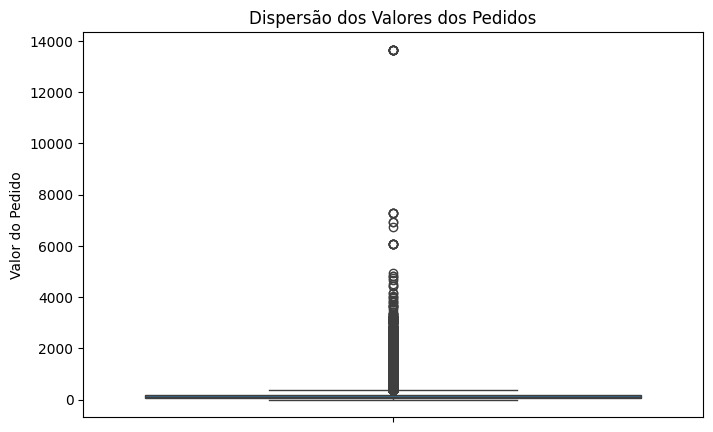

In [ ]:
plt.figure(figsize=(8,5))

sns.boxplot(
    y=df_olist_filtrado["payment_value"]
)

plt.title("Dispersão dos Valores dos Pedidos")
plt.ylabel("Valor do Pedido")
plt.show()

In [ ]:
receita_total = df_olist_filtrado["price"].sum()
total_pedidos = df_olist_filtrado["order_id"].nunique()
ticket_medio = receita_total / total_pedidos

print(f"Receita total: R$ {receita_total:,.2f}")
print(f"Total de pedidos: {total_pedidos}")
print(f"Ticket médio: R$ {ticket_medio:,.2f}")

Receita total: R$ 14,222,207.47
Total de pedidos: 98353
Ticket médio: R$ 144.60


## Evolução mensal dos pedidos

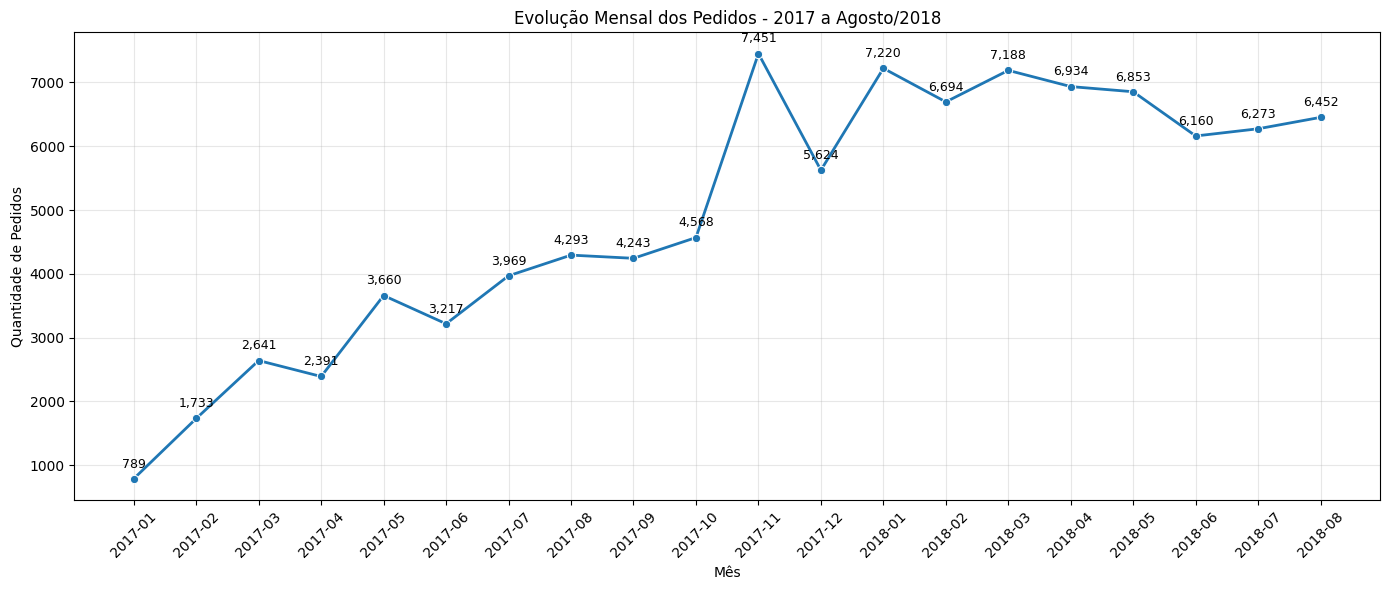

In [ ]:
df_olist_filtrado["ano_mes"] = (
    df_olist_filtrado["order_purchase_timestamp"]
    .dt.to_period("M")
    .astype(str)
)

pedidos_mes = (
    df_olist_filtrado
    .groupby("ano_mes")["order_id"]
    .nunique()
    .reset_index()
)

pedidos_mes.columns = [
    "Mês",
    "Quantidade de Pedidos"
]

plt.figure(figsize=(14,6))

sns.lineplot(
    data=pedidos_mes,
    x="Mês",
    y="Quantidade de Pedidos",
    marker="o",
    linewidth=2
)

# Adiciona os valores em cada ponto
for i, valor in enumerate(pedidos_mes["Quantidade de Pedidos"]):
    plt.annotate(
        f"{valor:,}",
        (i, valor),
        textcoords="offset points",
        xytext=(0,8),
        ha="center",
        fontsize=9
    )

plt.title("Evolução Mensal dos Pedidos - 2017 a Agosto/2018")
plt.xlabel("Mês")
plt.ylabel("Quantidade de Pedidos")
plt.xticks(rotation=45)
plt.grid(True, alpha=0.3)

plt.tight_layout()
plt.show()

## Receita mensal

In [ ]:
receita_mes = (df_olist_filtrado.groupby("order_purchase_timestamp_MMAAAA")["payment_value"].sum())
receita_mes

,payment_value
order_purchase_timestamp_MMAAAA,
2017-01,189570.02
2017-02,346280.99
2017-03,529993.27
2017-04,506900.50
2017-05,730912.77
2017-06,605639.30
2017-07,741936.39
2017-08,878027.04
2017-09,1022896.05


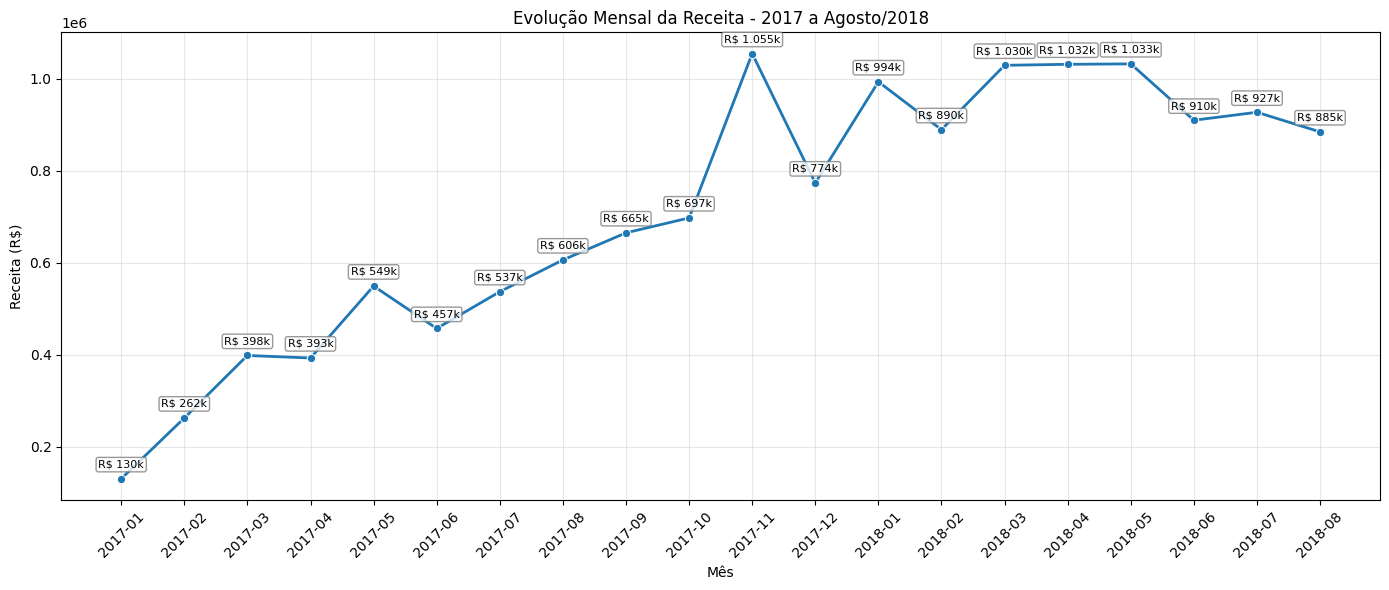

In [ ]:
df_olist_filtrado["ano_mes"] = (
    df_olist_filtrado["order_purchase_timestamp"]
    .dt.to_period("M")
    .astype(str)
)

receita_mes = (
    df_olist_filtrado
    .groupby("ano_mes")["price"]
    .sum()
    .reset_index()
)

receita_mes.columns = [
    "Mês",
    "Receita"
]

plt.figure(figsize=(14,6))

sns.lineplot(
    data=receita_mes,
    x="Mês",
    y="Receita",
    marker="o",
    linewidth=2
)

# Adicionar os valores da receita nos pontos
for i, valor in enumerate(receita_mes["Receita"]):
    plt.annotate(
        f"R$ {valor/1000:,.0f}k".replace(",", "."),
        (i, valor),
        textcoords="offset points",
        xytext=(0,8),
        ha="center",
        fontsize=8,
        bbox=dict(
            boxstyle="round,pad=0.2",
            fc="white",
            ec="gray",
            alpha=0.8
        )
    )

plt.title("Evolução Mensal da Receita - 2017 a Agosto/2018")
plt.xlabel("Mês")
plt.ylabel("Receita (R$)")
plt.xticks(rotation=45)
plt.grid(True, alpha=0.3)

plt.tight_layout()
plt.show()

In [ ]:
receita_ano = (
    df_olist_filtrado
    .groupby(
        df_olist_filtrado["order_purchase_timestamp"].dt.year
    )["payment_value"]
    .sum()
    .reset_index()
)

receita_ano.columns = [
    "Ano",
    "Receita"
]

receita_ano["Receita"] = (
    receita_ano["Receita"]
    .round(2)
)

receita_ano

for _, row in receita_ano.iterrows():
    print(
        f"{int(row['Ano'])}: "
        f"R$ {row['Receita']:,.2f}".replace(",", "X").replace(".", ",").replace("X", ".")
    )

2017: R$ 9.229.114,30
2018: R$ 11.112.841,18


In [ ]:
receita_2017 = receita_ano.loc[
    receita_ano["Ano"] == 2017,
    "Receita"
].values[0]

receita_2018 = receita_ano.loc[
    receita_ano["Ano"] == 2018,
    "Receita"
].values[0]

crescimento = (
    (receita_2018 - receita_2017)
    / receita_2017
) * 100

print(f"Crescimento: {crescimento:.2f}%")

Crescimento: 20.41%


In [ ]:
# Ticket Medio

ticket_medio = (df_olist_filtrado.groupby("order_purchase_timestamp_MMAAAA")["payment_value"].sum()/df_olist_filtrado.groupby("order_purchase_timestamp_MMAAAA")["order_id"].nunique())
ticket_medio

,0
order_purchase_timestamp_MMAAAA,
2017-01,240.266185
2017-02,199.815920
2017-03,200.679012
2017-04,212.003555
2017-05,199.702943
2017-06,188.262139
2017-07,186.932827
2017-08,204.525283
2017-09,241.078494


In [ ]:
pedidos_mensais = (
    df_olist_filtrado
    .groupby("ano_mes")
    .agg(
        qtd_pedidos=("order_id", "nunique")
    )
    .reset_index()
)

pedidos_mensais.head()

,ano_mes,qtd_pedidos
0,2017-01,789
1,2017-02,1733
2,2017-03,2641
3,2017-04,2391
4,2017-05,3660


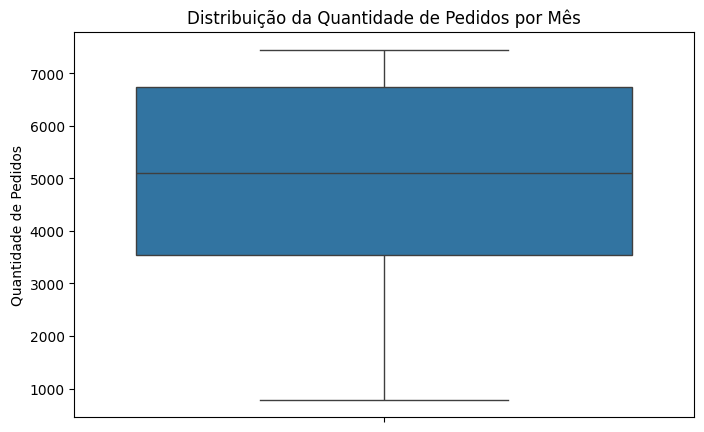

In [ ]:
plt.figure(figsize=(8,5))

sns.boxplot(
    y=pedidos_mensais["qtd_pedidos"]
)

plt.title(
    "Distribuição da Quantidade de Pedidos por Mês"
)

plt.ylabel(
    "Quantidade de Pedidos"
)

plt.show()

## Categorias mais vendidas

In [ ]:
categoria = (df_olist_filtrado.groupby("product_category_name")["order_id"].nunique().sort_values(ascending=False).head(10))
categoria



NameError: name 'df_olist_filtrado' is not defined

In [ ]:
categoria_receita = (
    df_olist_filtrado
    .groupby("product_category_name")["price"]
    .sum()
    .sort_values(ascending=False)
    .head(10)
)

categoria_receita

,price
product_category_name,
beleza_saude,1297140.69
relogios_presentes,1250962.71
cama_mesa_banho,1106770.10
esporte_lazer,1026270.24
informatica_acessorios,948480.47
moveis_decoracao,765501.41
utilidades_domesticas,667593.87
cool_stuff,663526.13
automotivo,616562.25


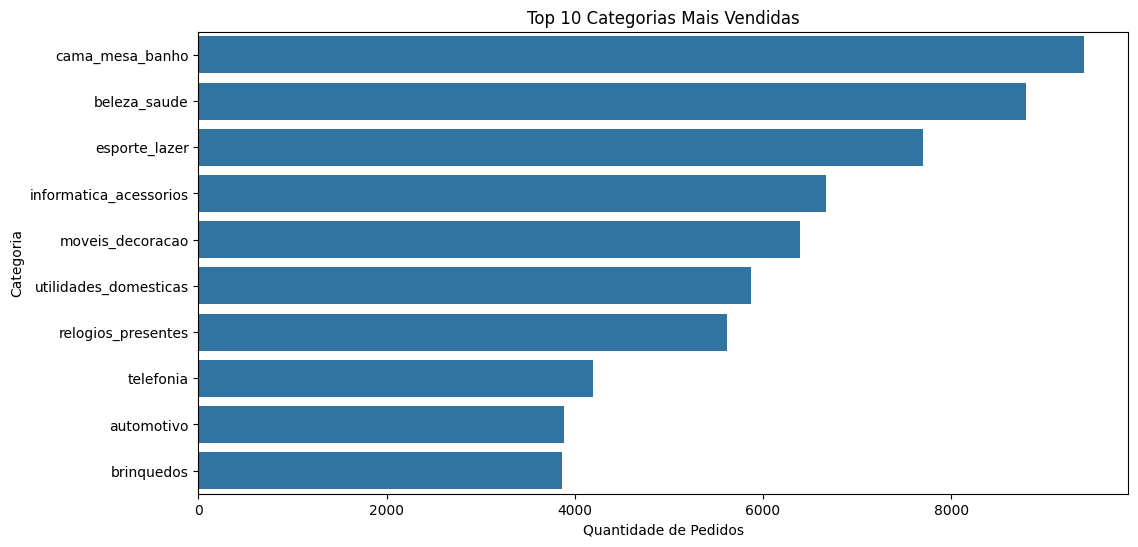

In [ ]:
categorias = df_olist_filtrado.groupby("product_category_name")["order_id"].nunique().reset_index()
categorias.columns = ["Categoria", "Quantidade de Pedidos"]

top_categorias = categorias.sort_values(
    by="Quantidade de Pedidos",
    ascending=False
).head(10)

plt.figure(figsize=(12,6))
sns.barplot(data=top_categorias, x="Quantidade de Pedidos", y="Categoria")

plt.title("Top 10 Categorias Mais Vendidas")
plt.xlabel("Quantidade de Pedidos")
plt.ylabel("Categoria")
plt.show()

In [ ]:
# Adicionar receita às categorias já existentes

receita_categoria = (
    df_olist_filtrado
    .groupby("product_category_name")["price"]
    .sum()
    .reset_index()
)

receita_categoria.columns = [
    "Categoria",
    "Receita Total"
]

top_categorias_comparativo = top_categorias.merge(
    receita_categoria,
    on="Categoria",
    how="left"
)

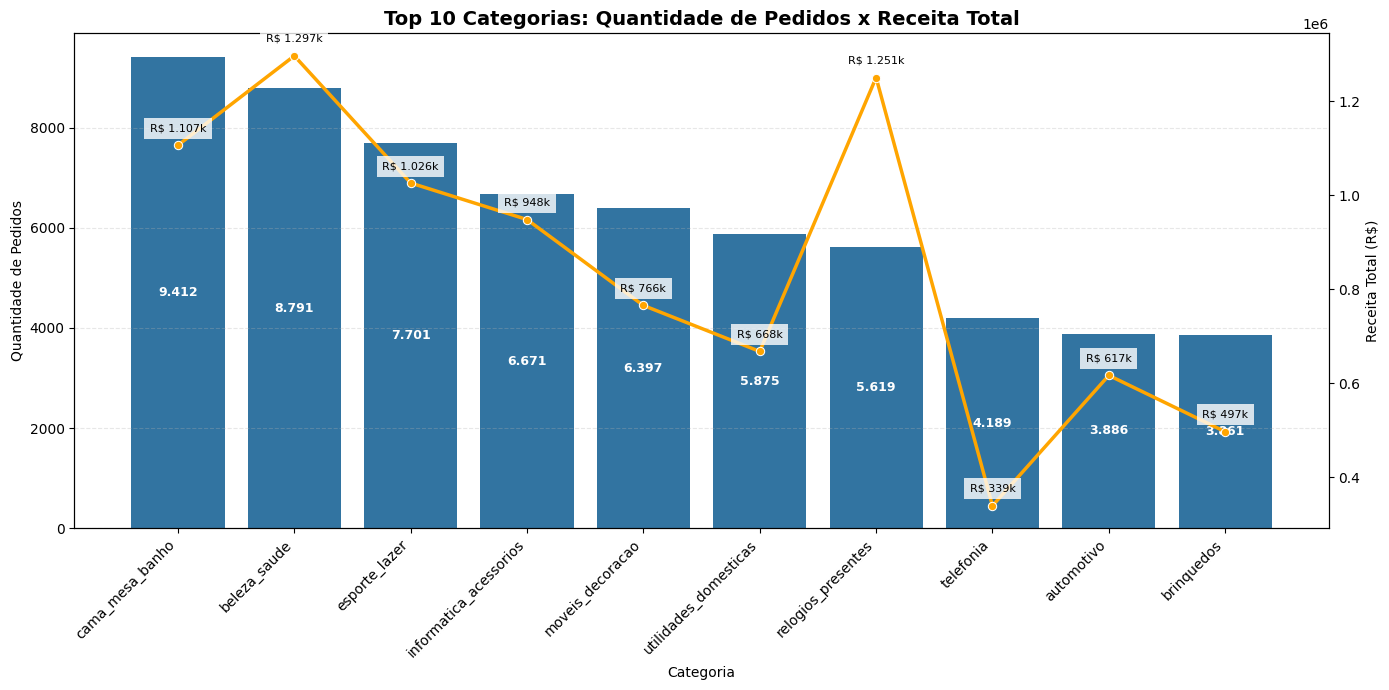

In [ ]:
# TOP 10 CATEGORIAS
# QUANTIDADE DE PEDIDOS x RECEITA TOTAL

# Base consolidada

top_categorias_comparativo = (
    df_olist_filtrado
    .groupby("product_category_name")
    .agg(
        Quantidade_Pedidos=("order_id", "nunique"),
        Receita_Total=("price", "sum")
    )
    .reset_index()
)

top_categorias_comparativo.columns = [
    "Categoria",
    "Quantidade de Pedidos",
    "Receita Total"
]

# Top 10 por quantidade de pedidos

top_categorias_comparativo = (
    top_categorias_comparativo
    .sort_values(
        by="Quantidade de Pedidos",
        ascending=False
    )
    .head(10)
)

# GRÁFICO

fig, ax1 = plt.subplots(figsize=(14,7))

# Barras = Quantidade de Pedidos

sns.barplot(
    data=top_categorias_comparativo,
    x="Categoria",
    y="Quantidade de Pedidos",
    ax=ax1
)

# Valores dentro das barras

for i, valor in enumerate(
    top_categorias_comparativo["Quantidade de Pedidos"]
):
    ax1.annotate(
        f"{valor:,}".replace(",", "."),
        (i, valor / 2),
        ha="center",
        va="center",
        fontsize=9,
        color="white",
        fontweight="bold"
    )

ax1.set_ylabel("Quantidade de Pedidos")
ax1.set_xlabel("Categoria")

# LINHA = RECEITA TOTAL

ax2 = ax1.twinx()

sns.lineplot(
    data=top_categorias_comparativo,
    x="Categoria",
    y="Receita Total",
    marker="o",
    color="orange",
    linewidth=2.5,
    ax=ax2
)

# Valores da receita (em K)

for i, valor in enumerate(
    top_categorias_comparativo["Receita Total"]
):
    ax2.annotate(
        f"R$ {valor/1000:,.0f}k".replace(",", "."),
        (i, valor),
        textcoords="offset points",
        xytext=(0,10),
        ha="center",
        fontsize=8,
        color="black",
        bbox=dict(
            facecolor="white",
            alpha=0.8,
            edgecolor="none"
        )
    )

ax2.set_ylabel("Receita Total (R$)")

# FORMATAÇÃO

plt.title(
    "Top 10 Categorias: Quantidade de Pedidos x Receita Total",
    fontsize=14,
    fontweight="bold"
)

ax1.grid(
    axis="y",
    linestyle="--",
    alpha=0.3
)

# Rotacionar categorias

plt.setp(
    ax1.get_xticklabels(),
    rotation=45,
    ha="right"
)

plt.tight_layout()

plt.show()

## Estados com maior volume de compras

In [ ]:
uf = (df_olist_merge.groupby("customer_state")["order_id"].nunique().sort_values(ascending=False))
uf

,order_id
customer_state,
SP,41374
RJ,12762
MG,11544
RS,5432
PR,4998
SC,3612
BA,3358
DF,2125
ES,2025


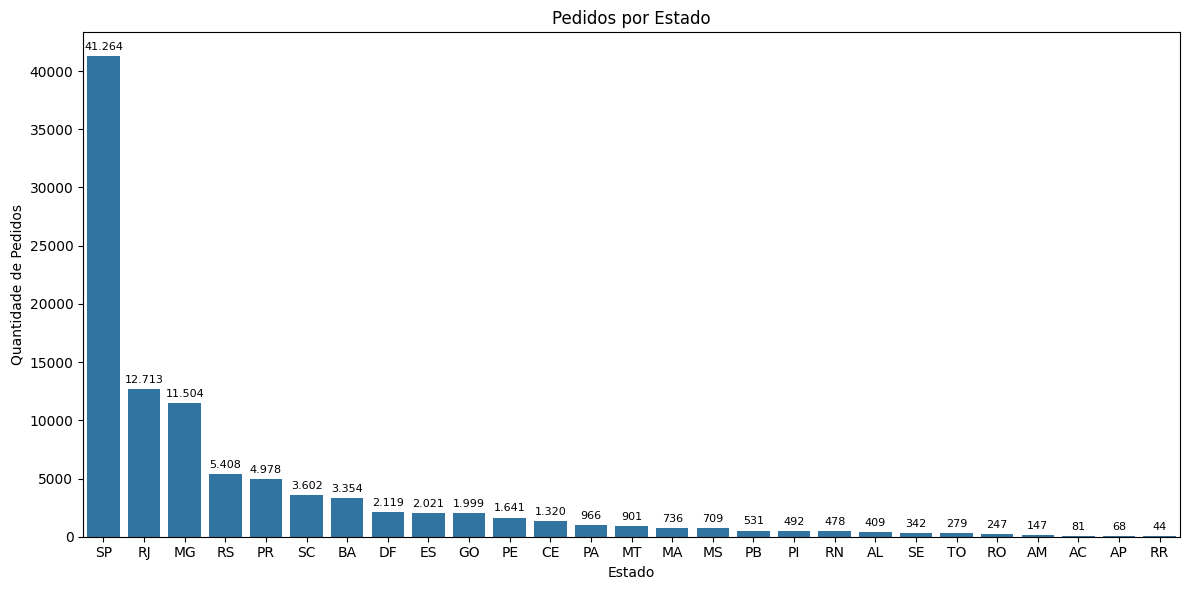

In [ ]:
pedidos_estado = (
    df_olist_filtrado
    .groupby("customer_state")["order_id"]
    .nunique()
    .reset_index()
)

pedidos_estado.columns = [
    "Estado",
    "Quantidade de Pedidos"
]

pedidos_estado = pedidos_estado.sort_values(
    by="Quantidade de Pedidos",
    ascending=False
)

plt.figure(figsize=(12,6))

ax = sns.barplot(
    data=pedidos_estado,
    x="Estado",
    y="Quantidade de Pedidos"
)

# Adicionar quantidade sobre cada barra
for p in ax.patches:
    altura = p.get_height()

    ax.annotate(
        f"{int(altura):,}".replace(",", "."),
        (
            p.get_x() + p.get_width() / 2,
            altura
        ),
        ha="center",
        va="bottom",
        fontsize=8,
        xytext=(0, 3),
        textcoords="offset points"
    )

plt.title("Pedidos por Estado")
plt.xlabel("Estado")
plt.ylabel("Quantidade de Pedidos")

plt.tight_layout()
plt.show()

In [ ]:
municipio = (df_olist_merge.groupby("customer_city")["payment_value"].nunique().sort_values(ascending=False).head(15))
municipio

,payment_value
customer_city,
sao paulo,8516
rio de janeiro,4625
belo horizonte,2220
brasilia,1708
curitiba,1319
campinas,1289
porto alegre,1208
salvador,1106
guarulhos,1074


In [ ]:
# Receita média por cliente

clientes_estado = df_olist_filtrado.groupby("customer_state").agg(
    receita_total=("price","sum"),
    clientes=("customer_unique_id","nunique")
).reset_index()

clientes_estado["receita_por_cliente"] = (
    clientes_estado["receita_total"] /
    clientes_estado["clientes"]
)

clientes_estado = clientes_estado.sort_values(
    by="receita_por_cliente",
    ascending=False
)

clientes_estado.head(10)

,customer_state,receita_total,clientes,receita_por_cliente
14,PB,123766.34,515,240.322990
0,AC,17059.44,77,221.551169
1,AL,83231.83,397,209.651965
26,TO,56251.91,272,206.808493
3,AP,13654.30,67,203.795522
19,RN,93879.17,467,201.026060
20,RO,46964.03,235,199.846936
12,MT,170781.95,871,196.075718
13,PA,183802.33,940,195.534394
16,PI,92017.70,480,191.703542


In [ ]:
# Base 1: participação dos pedidos por estado
pedidos_estado = df_olist_filtrado.groupby("customer_state")["order_id"].nunique().reset_index()
pedidos_estado.columns = ["Estado", "pedidos"]

total_pedidos = pedidos_estado["pedidos"].sum()

pedidos_estado["participacao_pedidos_%"] = (
    pedidos_estado["pedidos"] / total_pedidos * 100
)

# Base 2: receita média por cliente
clientes_estado = df_olist_filtrado.groupby("customer_state").agg(
    receita_total=("price", "sum"),
    clientes=("customer_unique_id", "nunique")
).reset_index()

clientes_estado.columns = [
    "Estado",
    "receita_total",
    "clientes"
]

clientes_estado["receita_por_cliente"] = (
    clientes_estado["receita_total"] / clientes_estado["clientes"]
)

# Juntar as duas bases
comparativo_estado = pedidos_estado.merge(
    clientes_estado,
    on="Estado",
    how="inner"
)

# Selecionar os 10 estados com maior participação
top10_comparativo = comparativo_estado.sort_values(
    by="participacao_pedidos_%",
    ascending=False
).head(10)

top10_comparativo

,Estado,pedidos,participacao_pedidos_%,receita_total,clientes,receita_por_cliente
25,SP,41264,41.954999,5461599.24,39875,136.968006
18,RJ,12713,12.925889,1909979.79,12256,155.840388
10,MG,11504,11.696644,1640789.47,11141,147.274883
22,RS,5408,5.498561,787540.22,5225,150.725401
17,PR,4978,5.061361,706658.91,4821,146.579322
23,SC,3602,3.662318,537523.14,3504,153.402723
4,BA,3354,3.410165,542349.94,3253,166.723006
6,DF,2119,2.154484,314078.52,2056,152.761926
7,ES,2021,2.054843,283853.51,1952,145.416757
8,GO,1999,2.032475,312133.98,1935,161.309550


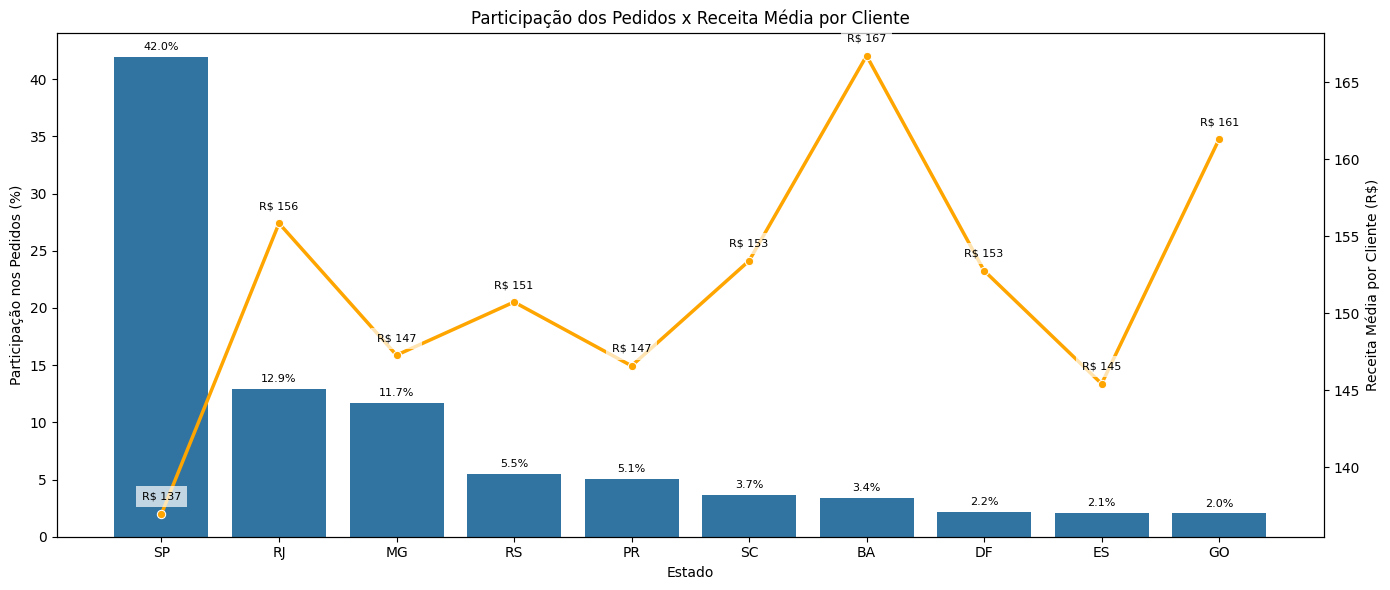

In [ ]:
fig, ax1 = plt.subplots(figsize=(14,6))

# Barras
sns.barplot(
    data=top10_comparativo,
    x="Estado",
    y="participacao_pedidos_%",
    ax=ax1
)

# Valores das barras
for i, valor in enumerate(top10_comparativo["participacao_pedidos_%"]):
    ax1.annotate(
        f"{valor:.1f}%",
        (i, valor),
        textcoords="offset points",
        xytext=(0,5),
        ha="center",
        fontsize=8
    )

ax1.set_ylabel("Participação nos Pedidos (%)")
ax1.set_xlabel("Estado")
ax1.set_title("Participação dos Pedidos x Receita Média por Cliente")

# Segundo eixo
ax2 = ax1.twinx()

sns.lineplot(
    data=top10_comparativo,
    x="Estado",
    y="receita_por_cliente",
    marker="o",
    color="orange",
    linewidth=2.5,
    ax=ax2
)

# Valores da linha
for i, valor in enumerate(top10_comparativo["receita_por_cliente"]):
    ax2.annotate(
        f"R$ {valor:,.0f}".replace(",", "."),
        (i, valor),
        textcoords="offset points",
        xytext=(0,10),
        ha="center",
        fontsize=8,
        color="black",
        bbox=dict(
            facecolor="white",
            alpha=0.7,
            edgecolor="none"
        )
    )

ax2.set_ylabel("Receita Média por Cliente (R$)")

plt.tight_layout()
plt.show()

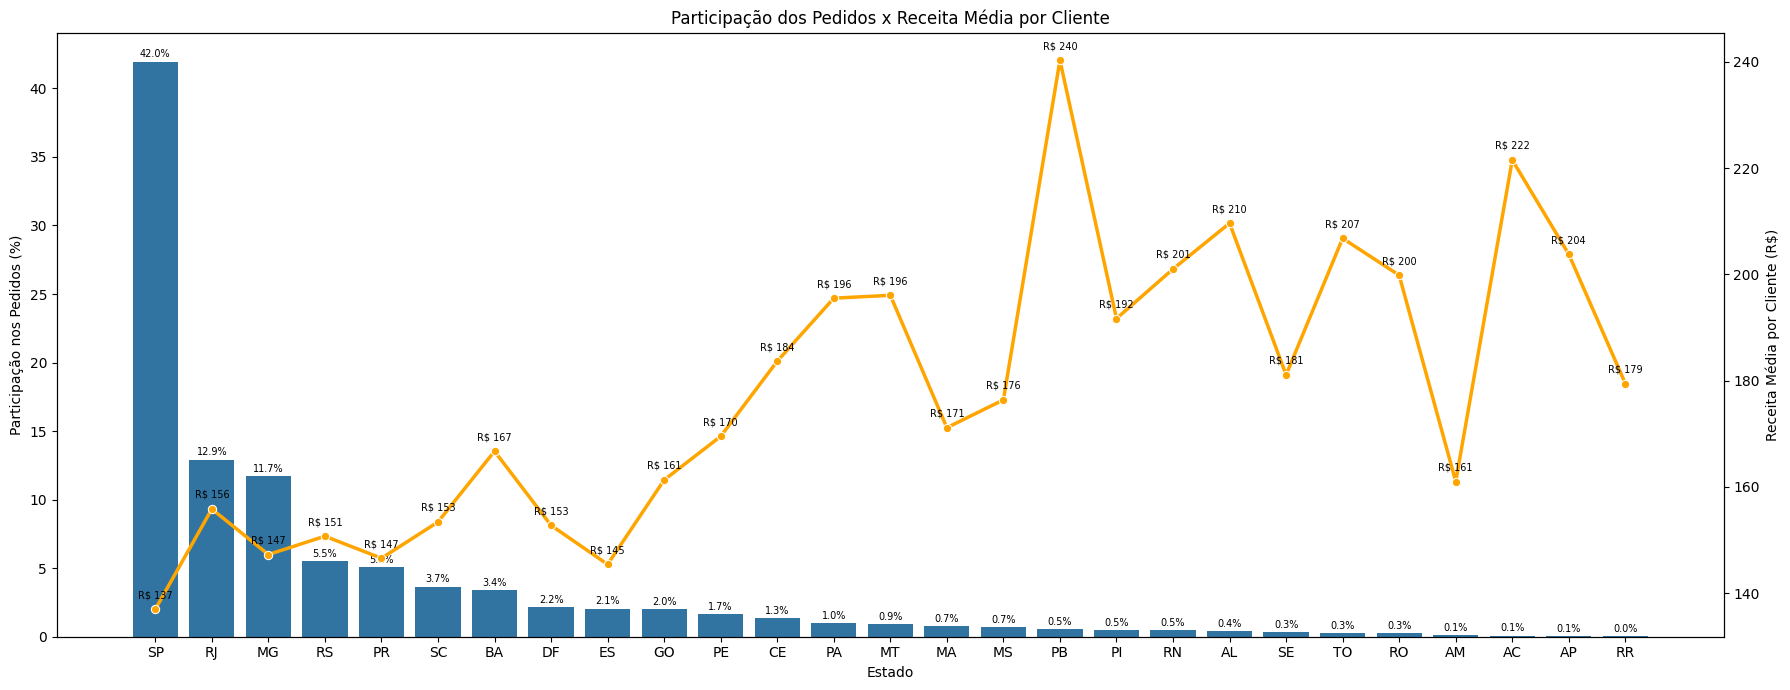

In [ ]:
fig, ax1 = plt.subplots(figsize=(18,7))

# Ordenar por participação nos pedidos
comparativo_estado_plot = comparativo_estado.sort_values(
    "participacao_pedidos_%",
    ascending=False
)

# Barras
sns.barplot(
    data=comparativo_estado_plot,
    x="Estado",
    y="participacao_pedidos_%",
    ax=ax1
)

# Valores das barras
for i, valor in enumerate(comparativo_estado_plot["participacao_pedidos_%"]):
    ax1.annotate(
        f"{valor:.1f}%",
        (i, valor),
        textcoords="offset points",
        xytext=(0, 3),
        ha="center",
        fontsize=7
    )

ax1.set_ylabel("Participação nos Pedidos (%)")
ax1.set_xlabel("Estado")
ax1.set_title("Participação dos Pedidos x Receita Média por Cliente")

# Segundo eixo
ax2 = ax1.twinx()

sns.lineplot(
    data=comparativo_estado_plot,
    x="Estado",
    y="receita_por_cliente",
    marker="o",
    color="orange",
    linewidth=2.5,
    ax=ax2
)

# Valores da linha
for i, valor in enumerate(comparativo_estado_plot["receita_por_cliente"]):
    ax2.annotate(
        f"R$ {valor:,.0f}".replace(",", "."),
        (i, valor),
        textcoords="offset points",
        xytext=(0, 8),
        ha="center",
        fontsize=7,
        color="black"
    )

ax2.set_ylabel("Receita Média por Cliente (R$)")

plt.xticks(rotation=45)
plt.tight_layout()
plt.show()

## Formas de pagamento mais utilizadas

In [ ]:
pagamentos = (
    order_payments["payment_type"]
    .value_counts()
    .reset_index()
)

pagamentos.columns = [
    "Forma de Pagamento",
    "Quantidade"
]

pagamentos["Participação (%)"] = (
    pagamentos["Quantidade"]
    / pagamentos["Quantidade"].sum()
    * 100
).round(2)

pagamentos

,Forma de Pagamento,Quantidade,Participação (%)
0,credit_card,76795,73.92
1,boleto,19784,19.04
2,voucher,5775,5.56
3,debit_card,1529,1.47
4,not_defined,3,0.00


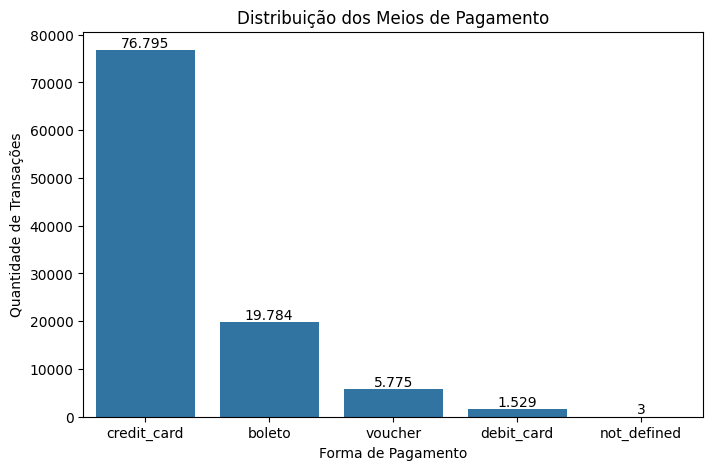

In [ ]:
plt.figure(figsize=(8,5))

ax = sns.barplot(
    data=pagamentos,
    x="Forma de Pagamento",
    y="Quantidade"
)

for p in ax.patches:
    ax.annotate(
        f'{int(p.get_height()):,}'.replace(',', '.'),
        (p.get_x() + p.get_width()/2, p.get_height()),
        ha='center',
        va='bottom'
    )

plt.title("Distribuição dos Meios de Pagamento")
plt.xlabel("Forma de Pagamento")
plt.ylabel("Quantidade de Transações")

plt.show()

In [ ]:
moda_parcelas = (
    order_payments["payment_installments"]
    .mode()[0]
)

print("Moda das parcelas:", moda_parcelas)

Moda das parcelas: 1


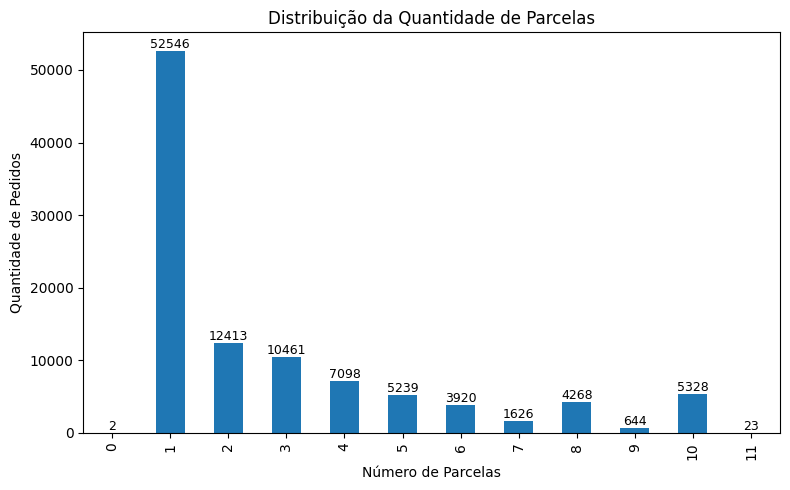

In [ ]:
plt.figure(figsize=(8,5))

ax = (
    order_payments["payment_installments"]
    .value_counts()
    .sort_index()
    .head(12)
    .plot(kind="bar")
)

plt.title("Distribuição da Quantidade de Parcelas")
plt.xlabel("Número de Parcelas")
plt.ylabel("Quantidade de Pedidos")

# Adiciona os valores nas barras
for p in ax.patches:
    ax.annotate(
        f'{int(p.get_height())}',
        (p.get_x() + p.get_width()/2, p.get_height()),
        ha='center',
        va='bottom',
        fontsize=9
    )

plt.tight_layout()
plt.show()

In [ ]:
payment_review = (
    df_olist_filtrado
    .groupby("payment_type")
    .agg(
        review_media=("review_score","mean"),
        ticket_medio=("payment_value","mean"),
        pedidos=("order_id","nunique")
    )
    .reset_index()
)

payment_review

,payment_type,review_media,ticket_medio,pedidos
0,boleto,4.026134,177.352446,19556
1,credit_card,4.034292,179.497202,75745
2,debit_card,4.156805,149.822687,1519
3,voucher,4.004314,64.702035,3755


## Tempo médio de entrega

In [ ]:
df_olist_filtrado["tempo_entrega_dias"] = (
    df_olist_filtrado["order_delivered_customer_date"] -
    df_olist_filtrado["order_purchase_timestamp"]
).dt.days

tempo_medio_entrega = df_olist_filtrado["tempo_entrega_dias"].mean()

print(f"Tempo médio de entrega: {tempo_medio_entrega:.2f} dias")

Tempo médio de entrega: 12.00 dias


## Pedidos atrasados x no prazo

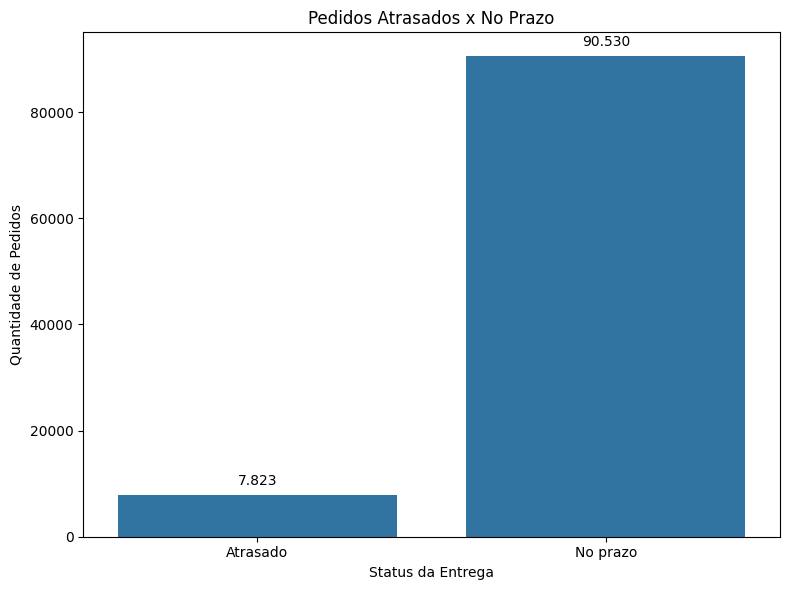

In [ ]:
df_olist_filtrado["status_entrega"] = np.where(
    df_olist_filtrado["order_delivered_customer_date"] >
    df_olist_filtrado["order_estimated_delivery_date"],
    "Atrasado",
    "No prazo"
)

status_entrega = (
    df_olist_filtrado
    .groupby("status_entrega")["order_id"]
    .nunique()
    .reset_index()
)

status_entrega.columns = [
    "Status",
    "Quantidade de Pedidos"
]

plt.figure(figsize=(8,6))

ax = sns.barplot(
    data=status_entrega,
    x="Status",
    y="Quantidade de Pedidos"
)

# Adicionar quantidade nas barras

for p in ax.patches:

    altura = p.get_height()

    ax.annotate(
        f"{int(altura):,}".replace(",", "."),
        (
            p.get_x() + p.get_width()/2,
            altura
        ),
        ha="center",
        va="bottom",
        fontsize=10,
        xytext=(0,5),
        textcoords="offset points"
    )

plt.title("Pedidos Atrasados x No Prazo")
plt.xlabel("Status da Entrega")
plt.ylabel("Quantidade de Pedidos")

plt.tight_layout()
plt.show()

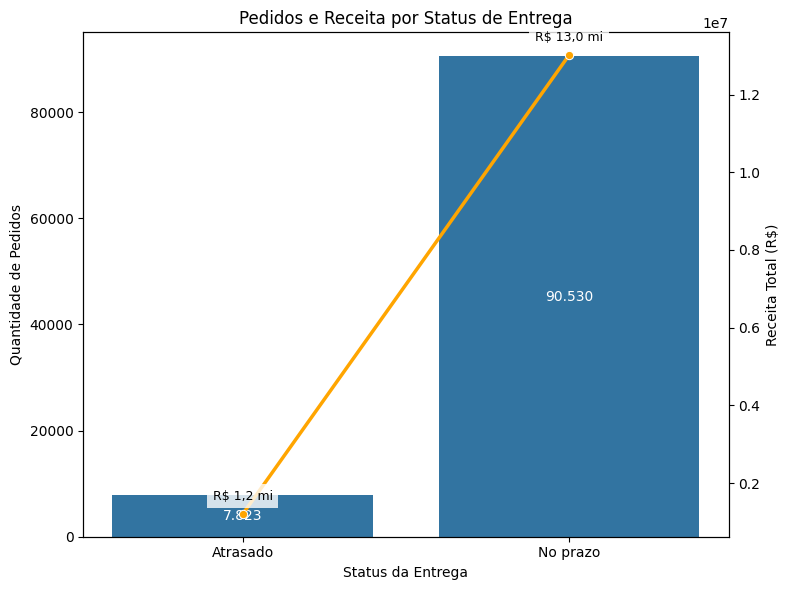

In [ ]:
# Comparação: Quantidade de Pedidos x Receita

status_entrega_comp = (
    df_olist_filtrado
    .groupby("status_entrega")
    .agg(
        Quantidade_Pedidos=("order_id", "nunique"),
        Receita_Total=("price", "sum")
    )
    .reset_index()
)

status_entrega_comp.columns = [
    "Status",
    "Quantidade de Pedidos",
    "Receita Total"
]

fig, ax1 = plt.subplots(figsize=(8,6))

# Barras = Quantidade

sns.barplot(
    data=status_entrega_comp,
    x="Status",
    y="Quantidade de Pedidos",
    ax=ax1
)

# Valores das barras

for i, valor in enumerate(status_entrega_comp["Quantidade de Pedidos"]):
    ax1.annotate(
        f"{valor:,}".replace(",", "."),
        (i, valor/2),
        ha="center",
        va="center",
        fontsize=10,
        color="white"
    )

ax1.set_ylabel("Quantidade de Pedidos")
ax1.set_xlabel("Status da Entrega")

# Linha = Receita

ax2 = ax1.twinx()

sns.lineplot(
    data=status_entrega_comp,
    x="Status",
    y="Receita Total",
    marker="o",
    color="orange",
    linewidth=2.5,
    ax=ax2
)

# Valores da receita

for i, valor in enumerate(status_entrega_comp["Receita Total"]):

    if valor >= 1_000_000:
        texto = f"R$ {valor/1_000_000:.1f} mi".replace(".", ",")
    else:
        texto = f"R$ {valor/1000:.0f} mil"

    ax2.annotate(
        texto,
        (i, valor),
        textcoords="offset points",
        xytext=(0,10),
        ha="center",
        fontsize=9,
        color="black",
        bbox=dict(
            facecolor="white",
            alpha=0.8,
            edgecolor="none"
        )
    )

ax2.set_ylabel("Receita Total (R$)")

plt.title(
    "Pedidos e Receita por Status de Entrega"
)

plt.tight_layout()
plt.show()

In [ ]:
df = pd.read_csv('/content/Heatmap.csv', sep = ';', decimal = ',')
df.head()

,regiao,ano_mes,total_pedidos,pct_no_prazo
0,Centro-Oeste,2017-01,41,0.95122
1,Centro-Oeste,2017-02,73,0.98630
2,Centro-Oeste,2017-03,136,0.97059
3,Centro-Oeste,2017-04,112,0.94643
4,Centro-Oeste,2017-05,206,0.98058


In [ ]:
# Reload data to ensure 'ano_mes' is in the original format (YYYY-MM)
df = pd.read_csv('/content/Heatmap.csv', sep=';', decimal=',')

portuguese_months = {
    1: 'Jan', 2: 'Fev', 3: 'Mar', 4: 'Abr', 5: 'Mai', 6: 'Jun',
    7: 'Jul', 8: 'Ago', 9: 'Set', 10: 'Out', 11: 'Nov', 12: 'Dez'
}

# 1. Convert to actual datetime objects for sorting
df['ano_mes_dt'] = pd.to_datetime(df['ano_mes'])

# 2. Create the Portuguese label
df['ano_mes_label'] = df['ano_mes_dt'].dt.month.map(portuguese_months) + '/' + df['ano_mes_dt'].dt.year.astype(str)

# 3. Define the chronological order based on the datetime objects
chronological_order = df.sort_values('ano_mes_dt')['ano_mes_label'].unique()

# 4. Set 'ano_mes' as a categorical column with the specific chronological order
df['ano_mes'] = pd.Categorical(df['ano_mes_label'], categories=chronological_order, ordered=True)

display(df.head())

,regiao,ano_mes,total_pedidos,pct_no_prazo,ano_mes_dt,ano_mes_label
0,Centro-Oeste,Jan/2017,41,0.95122,2017-01-01,Jan/2017
1,Centro-Oeste,Fev/2017,73,0.98630,2017-02-01,Fev/2017
2,Centro-Oeste,Mar/2017,136,0.97059,2017-03-01,Mar/2017
3,Centro-Oeste,Abr/2017,112,0.94643,2017-04-01,Abr/2017
4,Centro-Oeste,Mai/2017,206,0.98058,2017-05-01,Mai/2017


Plot saved as 'heatmap_entregas_no_prazo.png'


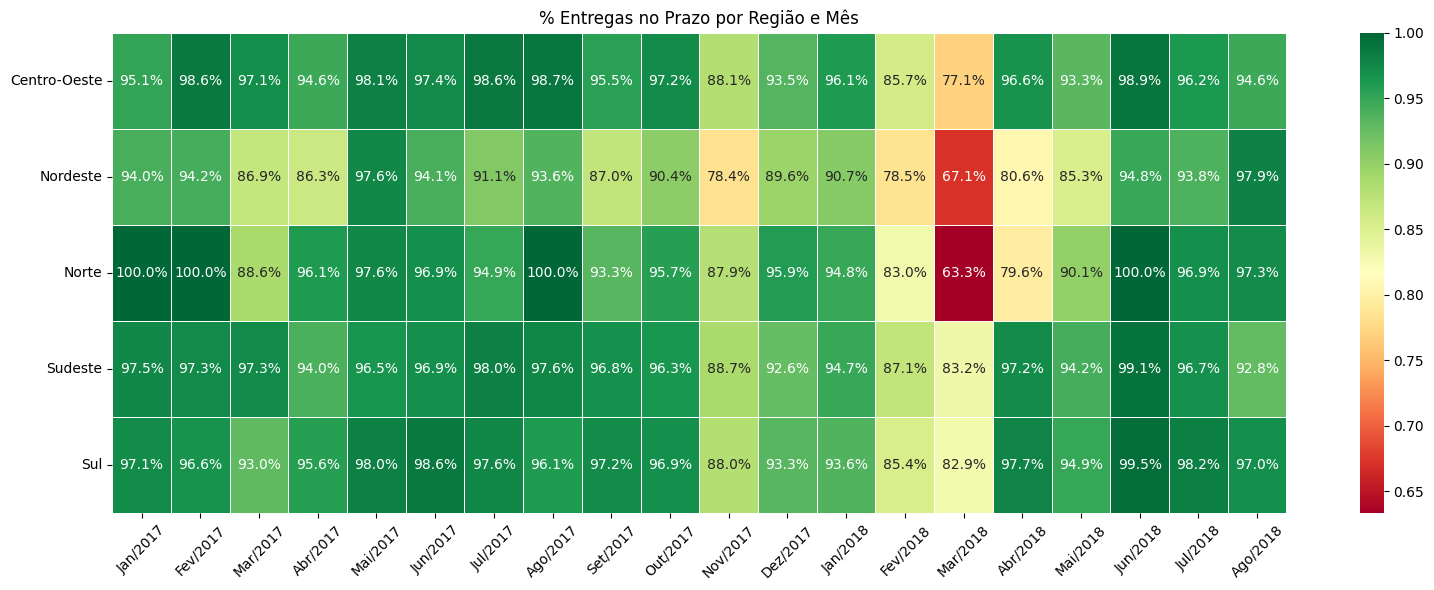

In [ ]:
pivot = df.pivot(index='regiao', columns='ano_mes', values='pct_no_prazo')

plt.figure(figsize=(16, 6))
sns.heatmap(
    pivot,
    annot=True,
    fmt='.1%',
    cmap='RdYlGn',
    linewidths=0.5
)
plt.title('% Entregas no Prazo por Região e Mês')
plt.xlabel('')
plt.ylabel('')
plt.xticks(rotation=45)
plt.yticks(rotation=360)
plt.tight_layout()
plt.savefig('heatmap_entregas_no_prazo.png')
print("Plot saved as 'heatmap_entregas_no_prazo.png'")
plt.show()

In [ ]:
%whos DataFrame

Variable                            Type         Data/Info
----------------------------------------------------------
categorias                          DataFrame                        Categ<...>\n\n[73 rows x 2 columns]
clientes_estado                     DataFrame       Estado  receita_total <...> 272           206.808493
comparativo_estado                  DataFrame       Estado  pedidos  parti<...>26           206.808493  
comparativo_estado_plot             DataFrame       Estado  pedidos  parti<...>21           179.461395  
customers                           DataFrame                             <...>n[99441 rows x 5 columns]
df                                  DataFrame              regiao   ano_me<...>n\n[100 rows x 6 columns]
df_olist                            DataFrame                             <...>\n[3095 rows x 4 columns]
df_olist_filtrado                   DataFrame                             <...>117917 rows x 44 columns]
df_olist_merge                      DataFr

In [ ]:
df_olist_filtrado["on_time"] = (
    df_olist_filtrado["order_delivered_customer_date"]
    <= df_olist_filtrado["order_estimated_delivery_date"]
)

df_olist_filtrado["Mês"] = (
    df_olist_filtrado["order_purchase_timestamp"]
    .dt.to_period("M")
    .astype(str)
)

df_olist_filtrado["Status"] = df_olist_filtrado["on_time"].map({
    True: "No Prazo",
    False: "Atrasado"
})

entregas_mes = (
    df_olist_filtrado
    .groupby(["Mês", "Status"])["order_id"]
    .nunique()
    .reset_index(name="Quantidade de Pedidos")
)

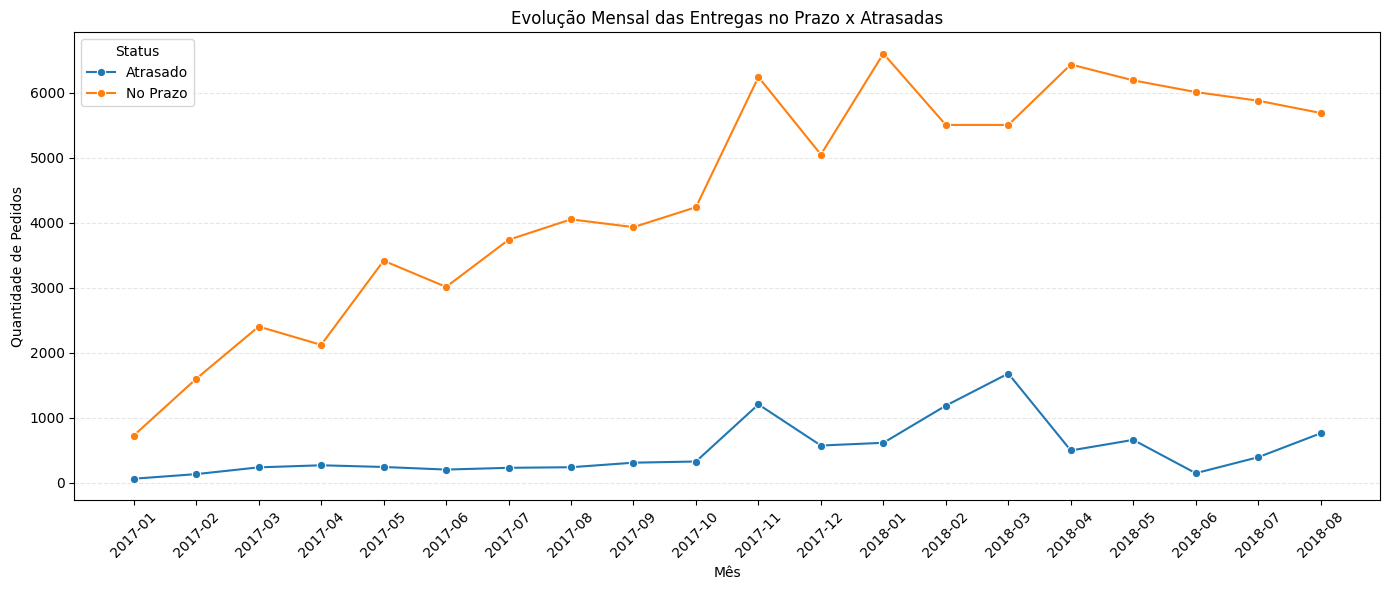

In [ ]:
plt.figure(figsize=(14,6))

ax = sns.lineplot(
    data=entregas_mes,
    x="Mês",
    y="Quantidade de Pedidos",
    hue="Status",
    marker="o"
)

plt.title(
    "Evolução Mensal das Entregas no Prazo x Atrasadas"
)

plt.xlabel("Mês")
plt.ylabel("Quantidade de Pedidos")

plt.xticks(rotation=45)

plt.grid(
    axis="y",
    linestyle="--",
    alpha=0.3
)

plt.tight_layout()

plt.show()

In [ ]:
# Quantidade de pedidos por mês e status

entregas_mes = (
    df_olist_filtrado
    .groupby(
        ["ano_mes", "status_entrega"]
    )["order_id"]
    .nunique()
    .reset_index()
)

entregas_mes.columns = [
    "Mês",
    "Status",
    "Quantidade de Pedidos"
]

# Tabela da taxa de atraso

taxa_atraso_mes = (
    entregas_mes
    .pivot(
        index="Mês",
        columns="Status",
        values="Quantidade de Pedidos"
    )
)

taxa_atraso_mes["Taxa_Atraso"] = (
    taxa_atraso_mes["Atrasado"] /
    (
        taxa_atraso_mes["Atrasado"] +
        taxa_atraso_mes["No prazo"]
    )
) * 100

taxa_atraso_mes.head(20)

Status,Atrasado,No prazo,Taxa_Atraso
Mês,,,
2017-01,23,766,2.915082
2017-02,53,1680,3.058280
2017-03,142,2499,5.376751
2017-04,181,2210,7.570054
2017-05,128,3532,3.497268
2017-06,121,3096,3.761268
2017-07,133,3836,3.350970
2017-08,139,4154,3.237829
2017-09,216,4027,5.090738


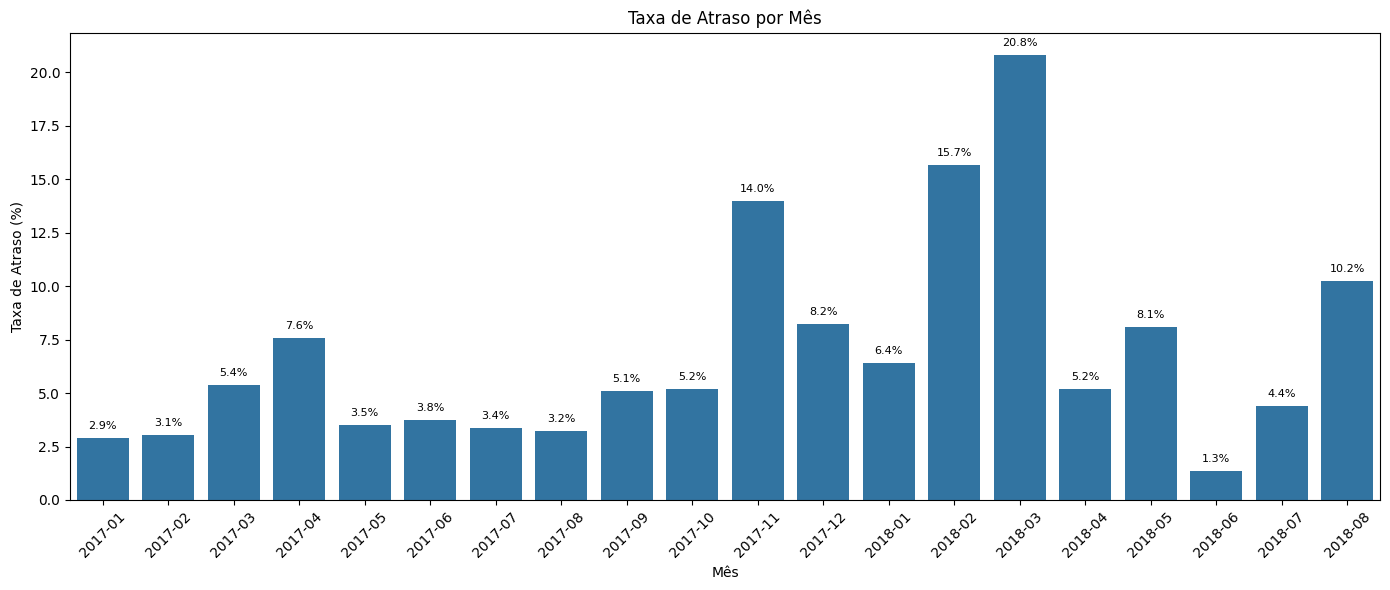

In [ ]:
taxa_atraso_plot = (
    taxa_atraso_mes
    .reset_index()
    .sort_values("Mês")
)

plt.figure(figsize=(14,6))

ax = sns.barplot(
    data=taxa_atraso_plot,
    x="Mês",
    y="Taxa_Atraso"
)

for p in ax.patches:

    altura = p.get_height()

    ax.annotate(
        f"{altura:.1f}%",
        (
            p.get_x() + p.get_width()/2,
            altura
        ),
        ha="center",
        va="bottom",
        fontsize=8,
        xytext=(0,5),
        textcoords="offset points"
    )

plt.title("Taxa de Atraso por Mês")
plt.xlabel("Mês")
plt.ylabel("Taxa de Atraso (%)")

plt.xticks(rotation=45)

plt.tight_layout()
plt.show()

## Relação entre atraso e avaliação

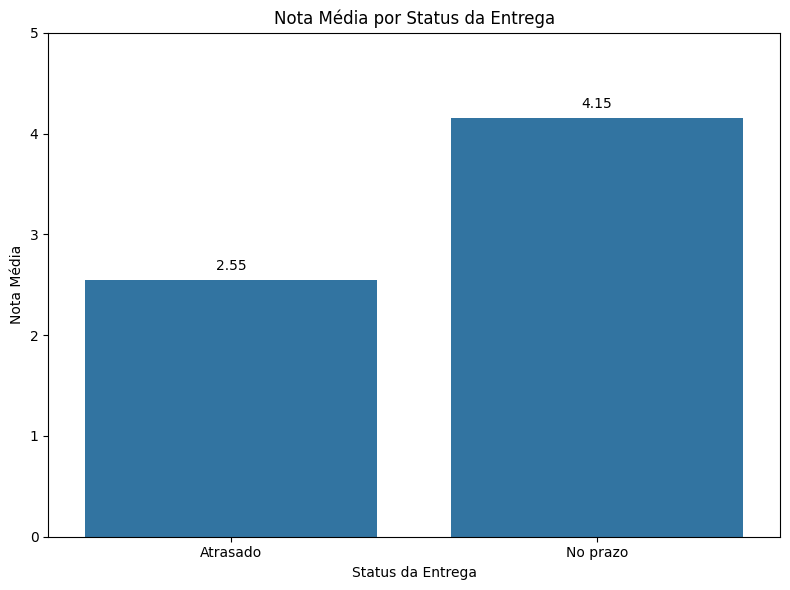

In [ ]:
avaliacao_entrega = (
    df_olist_filtrado
    .groupby("status_entrega")["review_score"]
    .mean()
    .reset_index()
)

avaliacao_entrega.columns = [
    "Status da Entrega",
    "Nota Média"
]

plt.figure(figsize=(8,6))

ax = sns.barplot(
    data=avaliacao_entrega,
    x="Status da Entrega",
    y="Nota Média"
)

# Adicionar nota média nas barras

for p in ax.patches:

    altura = p.get_height()

    ax.annotate(
        f"{altura:.2f}",
        (
            p.get_x() + p.get_width()/2,
            altura
        ),
        ha="center",
        va="bottom",
        fontsize=10,
        xytext=(0,5),
        textcoords="offset points"
    )

plt.title("Nota Média por Status da Entrega")
plt.xlabel("Status da Entrega")
plt.ylabel("Nota Média")
plt.ylim(0,5)

plt.tight_layout()
plt.show()

Boxplot da avaliação por status

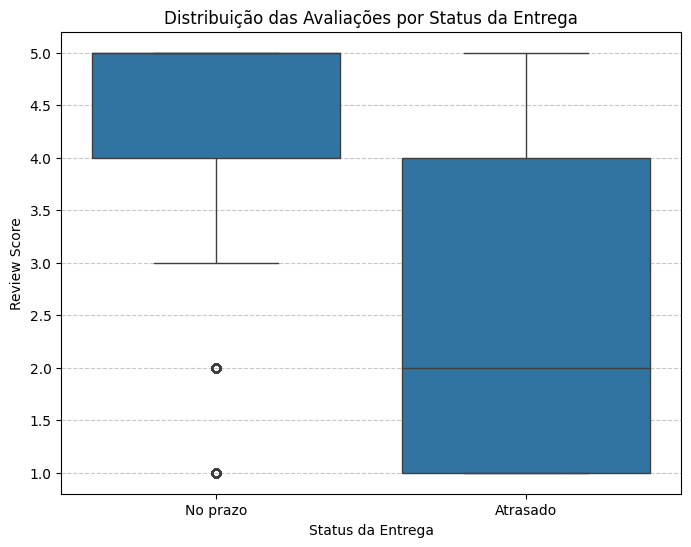

In [ ]:
plt.figure(figsize=(8,6))

sns.boxplot(
    data=df_olist_filtrado,
    x="status_entrega",
    y="review_score"
)

plt.title("Distribuição das Avaliações por Status da Entrega")
plt.xlabel("Status da Entrega")
plt.ylabel("Review Score")
plt.grid(axis="y", linestyle="--", alpha=0.7)
plt.show()

In [ ]:

df_olist_filtrado["dias_atraso"] = (
    df_olist_filtrado["order_delivered_customer_date"] -
    df_olist_filtrado["order_estimated_delivery_date"]
).dt.days

atraso_estado = (
    df_olist_filtrado
    .groupby("customer_state")
    .agg(
        atraso_medio=("dias_atraso", "mean"),
        satisfacao_media=("review_score", "mean"),
        pedidos=("order_id", "nunique")
    )
    .reset_index()
)

# Considerar apenas estados com volume relevante
atraso_estado = atraso_estado[
    atraso_estado["pedidos"] >= 100
]

atraso_estado = atraso_estado.sort_values(
    by="atraso_medio",
    ascending=False
)

atraso_estado.head(10)

,customer_state,atraso_medio,satisfacao_media,pedidos
1,AL,-8.486486,3.724289,409
9,MA,-9.621622,3.670659,736
24,SE,-9.882507,3.821429,342
7,ES,-10.565875,3.987041,2021
4,BA,-10.963770,3.819950,3354
5,CE,-11.165554,3.819363,1320
25,SP,-11.181415,4.128444,41264
11,MS,-11.250000,4.076112,709
16,PI,-11.414105,3.851852,492
23,SC,-11.520114,4.003982,3602


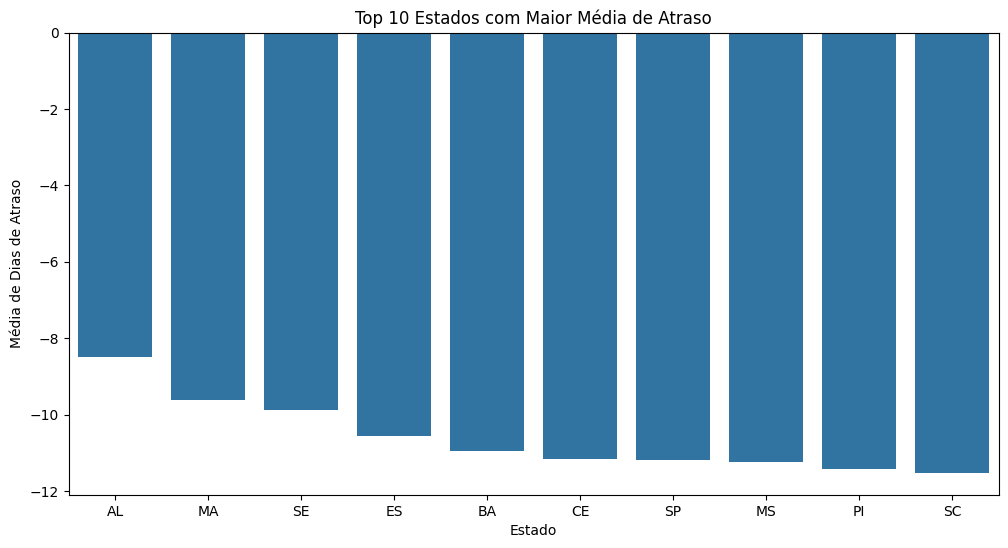

In [ ]:
plt.figure(figsize=(12,6))

sns.barplot(
    data=atraso_estado.head(10),
    x="customer_state",
    y="atraso_medio"
)

plt.title("Top 10 Estados com Maior Média de Atraso")
plt.xlabel("Estado")
plt.ylabel("Média de Dias de Atraso")

plt.show()

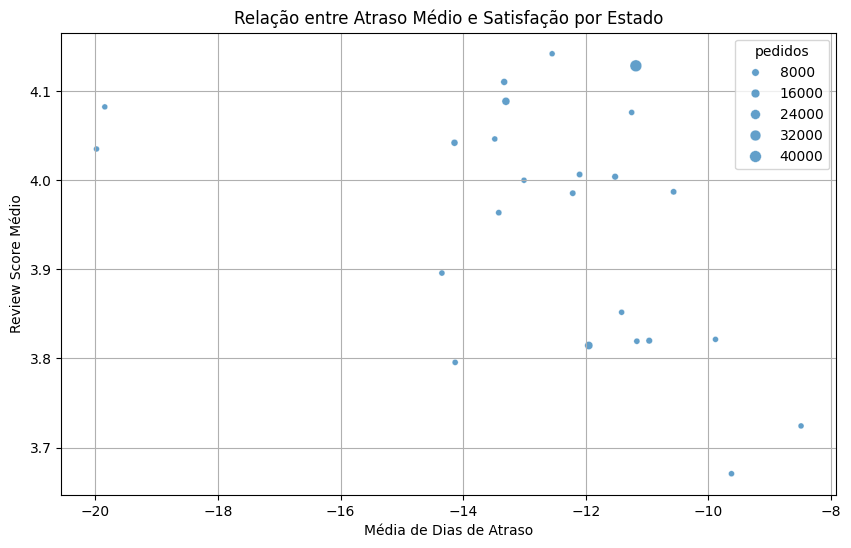

In [ ]:
plt.figure(figsize=(10,6))

sns.scatterplot(
    data=atraso_estado,
    x="atraso_medio",
    y="satisfacao_media",
    size="pedidos",
    alpha=0.7
)

plt.title("Relação entre Atraso Médio e Satisfação por Estado")
plt.xlabel("Média de Dias de Atraso")
plt.ylabel("Review Score Médio")

plt.grid(True)

plt.show()

In [ ]:
print("Análise de atraso x satisfação por estado:")

estado_maior_atraso = atraso_estado.iloc[0]["customer_state"]
maior_atraso = atraso_estado.iloc[0]["atraso_medio"]
satisfacao_estado = atraso_estado.iloc[0]["satisfacao_media"]

print(
    f"- O estado com maior média de atraso foi {estado_maior_atraso}, "
    f"com média de {maior_atraso:.2f} dias em relação ao prazo estimado."
)

print(
    f"- A satisfação média nesse estado foi de {satisfacao_estado:.2f}, "
    "indicando que atrasos logísticos podem impactar negativamente a percepção dos clientes."
)

print(
    "- A análise mostra que estados com maior atraso médio devem ser priorizados "
    "em ações de melhoria logística, pois representam risco para a experiência do cliente."
)

Análise de atraso x satisfação por estado:
- O estado com maior média de atraso foi AL, com média de -8.49 dias em relação ao prazo estimado.
- A satisfação média nesse estado foi de 3.72, indicando que atrasos logísticos podem impactar negativamente a percepção dos clientes.
- A análise mostra que estados com maior atraso médio devem ser priorizados em ações de melhoria logística, pois representam risco para a experiência do cliente.


In [ ]:
satisfacao_estado = (
    df_olist_filtrado
    .groupby("customer_state")
    .agg(
        satisfacao_media=("review_score", "mean"),
        tempo_medio_entrega=("tempo_entrega_dias", "mean"),
        pedidos=("order_id", "nunique")
    )
    .reset_index()
)

# Remover estados com poucos pedidos
satisfacao_estado = satisfacao_estado[
    satisfacao_estado["pedidos"] >= 100
]

satisfacao_estado = satisfacao_estado.sort_values(
    by="satisfacao_media",
    ascending=False
)

satisfacao_estado.head(10)

,customer_state,satisfacao_media,tempo_medio_entrega,pedidos
26,TO,4.142012,16.664671,279
25,SP,4.128444,8.249266,41264
17,PR,4.110343,11.497953,4978
10,MG,4.088617,11.475953,11504
2,AM,4.082353,26.064706,147
11,MS,4.076112,15.057783,709
19,RN,4.046346,19.105735,478
22,RS,4.042071,14.694479,5408
20,RO,4.035088,19.234875,247
6,DF,4.006467,12.465765,2119


In [ ]:
melhor_estado = satisfacao_estado.iloc[0]

print(
    f"Estado com maior satisfação: {melhor_estado['customer_state']}"
)

print(
    f"Review médio: {melhor_estado['satisfacao_media']:.2f}"
)

print(
    f"Tempo médio de entrega: {melhor_estado['tempo_medio_entrega']:.2f} dias"
)

print(
    f"Pedidos analisados: {melhor_estado['pedidos']}"
)

Estado com maior satisfação: TO
Review médio: 4.14
Tempo médio de entrega: 16.66 dias
Pedidos analisados: 279


In [ ]:
ranking_estados = satisfacao_estado.copy()

ranking_estados["score"] = (
    ranking_estados["satisfacao_media"] /
    ranking_estados["tempo_medio_entrega"]
)

ranking_estados.sort_values(
    by="score",
    ascending=False
).head(10)

,customer_state,satisfacao_media,tempo_medio_entrega,pedidos,score
25,SP,4.128444,8.249266,41264,0.500462
17,PR,4.110343,11.497953,4978,0.357485
10,MG,4.088617,11.475953,11504,0.356277
6,DF,4.006467,12.465765,2119,0.321398
23,SC,4.003982,14.488878,3602,0.276349
22,RS,4.042071,14.694479,5408,0.275074
11,MS,4.076112,15.057783,709,0.270698
8,GO,3.985459,14.907873,1999,0.267339
7,ES,3.987041,15.222894,2021,0.261911
18,RJ,3.814566,14.745707,12713,0.258690


## Categorias com piores avaliações

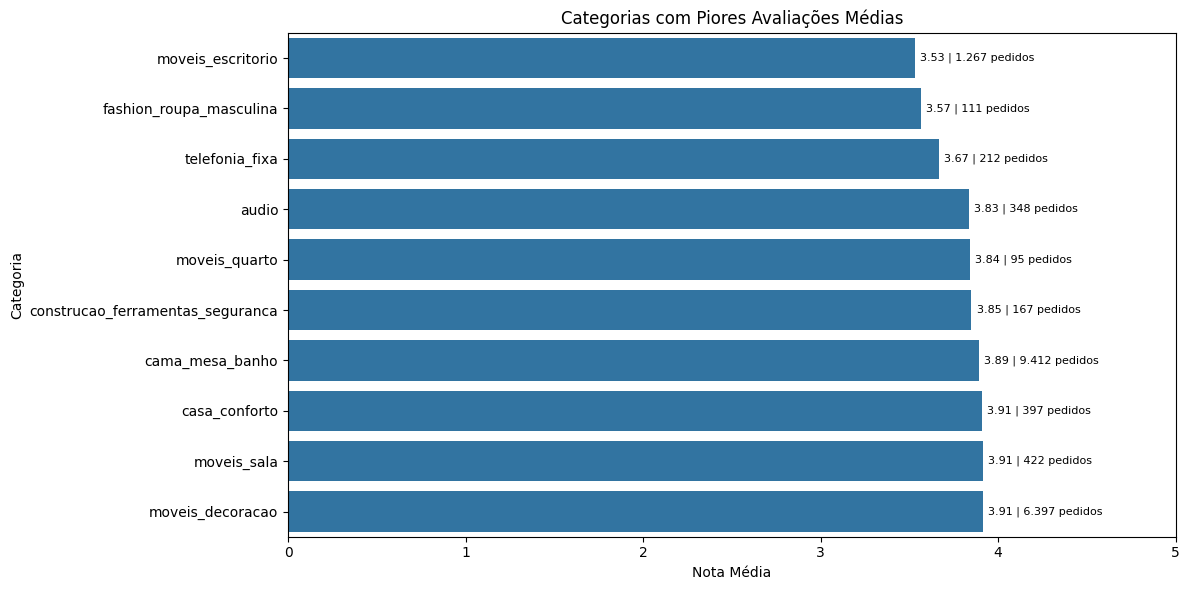

In [ ]:
# Média das avaliações por categoria

avaliacao_categoria = (
    df_olist_filtrado
    .groupby("product_category_name")
    .agg(
        nota_media=("review_score", "mean"),
        qtd_pedidos=("order_id", "nunique")
    )
    .reset_index()
)

avaliacao_categoria = avaliacao_categoria[
    avaliacao_categoria["qtd_pedidos"] >= 50
]

piores_categorias = (
    avaliacao_categoria
    .sort_values(by="nota_media")
    .head(10)
)

plt.figure(figsize=(12,6))

ax = sns.barplot(
    data=piores_categorias,
    x="nota_media",
    y="product_category_name"
)

# Adicionar nota média e quantidade de pedidos

for i, row in piores_categorias.iterrows():

    ax.text(
        row["nota_media"] + 0.03,
        list(piores_categorias.index).index(i),
        f'{row["nota_media"]:.2f} | {int(row["qtd_pedidos"]):,} pedidos'.replace(",", "."),
        va="center",
        fontsize=8
    )

plt.title("Categorias com Piores Avaliações Médias")
plt.xlabel("Nota Média")
plt.ylabel("Categoria")
plt.xlim(0,5)

plt.tight_layout()
plt.show()

In [ ]:
comentarios_ruins = (
    df_olist_filtrado[
        (df_olist_filtrado["review_score"] <= 2) &
        (df_olist_filtrado["review_comment_message"].notna())
    ][[
        "review_score",
        "product_category_name",
        "status_entrega",
        "review_comment_message"
    ]]
)

comentarios_ruins.sample(30)

,review_score,product_category_name,status_entrega,review_comment_message
22817,1.0,informatica_acessorios,No prazo,Sem comentários
77133,1.0,construcao_ferramentas_ferramentas,No prazo,"Faltando parte do produto, já foi solicitada a..."
63128,1.0,beleza_saude,No prazo,Essa já é a quarta ou quinta compra minha que ...
38854,2.0,automotivo,No prazo,Um excelente site. Super recomendo.
64290,1.0,casa_construcao,No prazo,Recebi o produto porém veio com a tela quebrad...
107726,1.0,ferramentas_jardim,No prazo,Pedi duas cubas so recebi uma estou aguardando...
50880,2.0,moveis_escritorio,No prazo,"A cadeira não atingiu minhas expectativas, não..."
45551,1.0,bebes,No prazo,Recebi só as mamadeiras mandei email questiona...
62124,1.0,esporte_lazer,No prazo,Satisfeito
77410,1.0,alimentos,No prazo,Faltou um dos itens


In [ ]:
lista_piores = piores_categorias[
    "product_category_name"
].tolist()

comentarios_piores = (
    df_olist_filtrado[
        (df_olist_filtrado["product_category_name"].isin(lista_piores))
        &
        (df_olist_filtrado["review_score"] <= 2)
        &
        (df_olist_filtrado["review_comment_message"].notna())
    ][[
        "product_category_name",
        "review_score",
        "status_entrega",
        "review_comment_message"
    ]]
)

comentarios_piores.head(50)

,product_category_name,review_score,status_entrega,review_comment_message
67,moveis_decoracao,1.0,Atrasado,Não recebi
132,moveis_decoracao,1.0,Atrasado,Não recebi o produto até a presente data na mi...
150,moveis_escritorio,1.0,No prazo,mais ou menos o produto veio faltando uma peca
153,cama_mesa_banho,1.0,No prazo,Produto não corresponde às expectativas
212,moveis_escritorio,1.0,No prazo,Faltou a FLANGE da cadeira que e considerada a...
261,cama_mesa_banho,1.0,No prazo,Comprei um lençol queen mas as fronhas não ves...
318,moveis_decoracao,1.0,Atrasado,Comprei um KiT de 3 Almofadas Azul Mandala e r...
362,construcao_ferramentas_seguranca,1.0,No prazo,targaryen não entregou os produtos completos. ...
363,construcao_ferramentas_seguranca,1.0,No prazo,targaryen não entregou os produtos completos. ...
476,cama_mesa_banho,1.0,No prazo,"Não recebi a quantidade correta, estou aguarda..."


In [ ]:
comentarios_negativos = (
    df_olist_filtrado[
        (df_olist_filtrado["review_score"] <= 2)
    ]
    .groupby("status_entrega")
    .agg(
        Avaliacoes_Negativas=("order_id","nunique")
    )
)

comentarios_negativos

,Avaliacoes_Negativas
status_entrega,
Atrasado,4144
No prazo,9707


In [ ]:
comentarios_piores[
    "review_comment_message"
].dropna().sample(20)

,review_comment_message
86599,Não recebi ainda
113911,"Ficou faltando um kit do produto, os pendente ..."
76294,a foto no site indicava uma unidade e nao um k...
63549,"Achei que a cortina e muito fina ,ela é tudo j..."
82190,"péssima embalagem , tive que colar ele todo, f..."
654,o produto não chegou
90348,Falta a entrega da Cúpula para abajur modelo t...
30909,"Valor do produto no site $175,00 mais frete de..."
36449,"Pedi duas cadeiras, e veio somente uma e ainda..."
21449,"Efetuei a compra de duas cortinas, mas recebi ..."


In [ ]:
comentarios_piores[
    "review_comment_message"
].dropna().sample(20)

,review_comment_message
96372,lannister ótima mais o produto é péssimo! Desc...
90933,Eu pedi dois kit e só chegou apenas um o outro...
47058,O prazo de entrega expirou em 28/12/17 e até o...
68934,estou esperando o produto que não chegou
31486,"Não existe pós venda, é impossível saber o sta..."
9062,"Recebi somente dois dos três produtos, e veio ..."
19195,Comprei 2 colcha chenille jolitex casal uma az...
18803,"Veio na cor errada , riscado muito danificado ..."
96283,"Não gostei do matéria das cotinas,achei muito ..."
81135,A compra foi de cinco almofadas marron. Só vie...


In [ ]:
# Receita total da operação

receita_total = df_olist_filtrado["price"].sum()

# Lista das 10 piores categorias

lista_piores = piores_categorias[
    "product_category_name"
].tolist()

# Receita das piores categorias

receita_piores = (
    df_olist_filtrado[
        df_olist_filtrado["product_category_name"]
        .isin(lista_piores)
    ]["price"]
    .sum()
)

# Percentual da receita

percentual_receita = (
    receita_piores /
    receita_total
) * 100

print(
    f"Receita das 10 categorias com piores avaliações: "
    f"R$ {receita_piores:,.2f}".replace(",", ".")
)

print(
    f"Participação na receita total: "
    f"{percentual_receita:.2f}%"
)

Receita das 10 categorias com piores avaliações: R$ 2.485.885.32
Participação na receita total: 17.48%


In [ ]:
ticket_categoria = (
    df_olist_filtrado
    .groupby("product_category_name")
    .agg(
        Receita_Total=("price", "sum"),
        Pedidos=("order_id", "nunique")
    )
)

ticket_categoria["Ticket_Medio"] = (
    ticket_categoria["Receita_Total"] /
    ticket_categoria["Pedidos"]
)

ticket_categoria = (
    ticket_categoria
    .sort_values(
        by="Ticket_Medio",
        ascending=False
    )
)

ticket_categoria.head(10)

,Receita_Total,Pedidos,Ticket_Medio
product_category_name,,,
pcs,242811.61,181,1341.500608
portateis_casa_forno_e_cafe,48945.71,75,652.609467
eletrodomesticos_2,123532.96,234,527.918632
agro_industria_e_comercio,83841.95,182,460.670055
instrumentos_musicais,210953.63,628,335.913424
eletroportateis,201839.56,630,320.380254
telefonia_fixa,61036.37,212,287.907406
portateis_cozinha_e_preparadores_de_alimentos,3968.53,14,283.466429
construcao_ferramentas_seguranca,41977.51,167,251.362335


In [ ]:
# RECOMPRA POR CATEGORIA

# Quantidade de pedidos por cliente dentro de cada categoria

cliente_categoria = (
    df_olist_filtrado
    .groupby([
        "product_category_name",
        "customer_unique_id"
    ])
    .agg(
        Pedidos_Cliente_Categoria=("order_id", "nunique")
    )
    .reset_index()
)

# Marcar se o cliente recomprou dentro da mesma categoria

cliente_categoria["Recomprou_Categoria"] = (
    cliente_categoria["Pedidos_Cliente_Categoria"] > 1
)

# Calcular clientes totais e clientes com recompra por categoria

recompra_categoria = (
    cliente_categoria
    .groupby("product_category_name")
    .agg(
        Clientes=("customer_unique_id", "nunique"),
        Clientes_Recompra=("Recomprou_Categoria", "sum")
    )
    .reset_index()
)

# Calcular taxa de recompra correta

recompra_categoria["Taxa_Recompra_%"] = (
    recompra_categoria["Clientes_Recompra"] /
    recompra_categoria["Clientes"]
) * 100

In [ ]:
# RESUMO COMERCIAL POR CATEGORIA

resumo_comercial = (
    df_olist_filtrado
    .groupby("product_category_name")
    .agg(
        Quantidade_Vendas=("order_id", "nunique"),
        Receita_Total=("price", "sum")
    )
    .reset_index()
)

resumo_comercial["Ticket_Medio"] = (
    resumo_comercial["Receita_Total"] /
    resumo_comercial["Quantidade_Vendas"]
)

# Juntar com recompra correta

resumo_produtos = resumo_comercial.merge(
    recompra_categoria,
    on="product_category_name",
    how="left"
)

# Arredondar valores

resumo_produtos["Receita_Total"] = resumo_produtos["Receita_Total"].round(2)

resumo_produtos["Ticket_Medio"] = resumo_produtos["Ticket_Medio"].round(2)

resumo_produtos["Taxa_Recompra_%"] = resumo_produtos["Taxa_Recompra_%"].round(2)

# Ordenar por maior receita e reiniciar índice

resumo_produtos = (
    resumo_produtos
    .sort_values(
        by="Receita_Total",
        ascending=False
    )
    .reset_index(drop=True)
)

# Criar ranking começando em 1

resumo_produtos.index = resumo_produtos.index + 1

resumo_produtos.head(20)

,product_category_name,Quantidade_Vendas,Receita_Total,Ticket_Medio,Clientes,Clientes_Recompra,Taxa_Recompra_%
1,beleza_saude,8791,1297140.69,147.55,8634,150,1.74
2,relogios_presentes,5619,1250962.71,222.63,5543,63,1.14
3,cama_mesa_banho,9412,1106770.10,117.59,9140,252,2.76
4,esporte_lazer,7701,1026270.24,133.26,7496,184,2.45
5,informatica_acessorios,6671,948480.47,142.18,6539,126,1.93
6,moveis_decoracao,6397,765501.41,119.67,6266,128,2.04
7,utilidades_domesticas,5875,667593.87,113.63,5812,61,1.05
8,cool_stuff,3624,663526.13,183.09,3607,17,0.47
9,automotivo,3886,616562.25,158.66,3841,43,1.12
10,ferramentas_jardim,3513,518113.45,147.48,3484,29,0.83


In [ ]:
# Clientes com quantidade de pedidos e categorias distintas

clientes_categorias = (
    df_olist_filtrado
    .groupby("customer_unique_id")
    .agg(
        Quantidade_Pedidos=("order_id", "nunique"),
        Categorias_Distintas=("product_category_name", "nunique")
    )
    .reset_index()
)

# Clientes que recompraram em categorias diferentes

clientes_recompra_categorias_diferentes = clientes_categorias[
    (clientes_categorias["Quantidade_Pedidos"] > 1) &
    (clientes_categorias["Categorias_Distintas"] > 1)
]

qtd_clientes_recompra_categorias_diferentes = len(
    clientes_recompra_categorias_diferentes
)

percentual_recompra_categorias_diferentes = (
    qtd_clientes_recompra_categorias_diferentes /
    clientes_categorias["customer_unique_id"].nunique()
) * 100

print(
    f"Clientes que recompraram em categorias diferentes: "
    f"{qtd_clientes_recompra_categorias_diferentes:,}"
    .replace(",", ".")
)

print(
    f"Percentual sobre o total de clientes: "
    f"{percentual_recompra_categorias_diferentes:.2f}%"
)

Clientes que recompraram em categorias diferentes: 1.569
Percentual sobre o total de clientes: 1.65%


In [ ]:
ticket_estado_categoria = (
    df_olist_filtrado
    .groupby(
        [
            "customer_state",
            "product_category_name"
        ]
    )
    .agg(
        Receita_Total=("price", "sum"),
        Pedidos=("order_id", "nunique")
    )
    .reset_index()
)

ticket_estado_categoria["Ticket_Medio"] = (
    ticket_estado_categoria["Receita_Total"] /
    ticket_estado_categoria["Pedidos"]
)

ticket_estado_categoria.sort_values(
    by="Ticket_Medio",
    ascending=False
).head(20)

,customer_state,product_category_name,Receita_Total,Pedidos,Ticket_Medio
644,MT,sinalizacao_e_seguranca,2919.40,1,2919.400000
351,ES,pcs,8058.00,3,2686.000000
413,GO,pcs,5259.97,2,2629.985000
1341,TO,eletrodomesticos_2,6606.85,3,2202.283333
737,PB,pcs,8468.00,4,2117.000000
1065,RO,portateis_casa_forno_e_cafe,1999.00,1,1999.000000
1362,TO,portateis_casa_forno_e_cafe,1999.00,1,1999.000000
292,DF,pcs,10786.99,6,1797.831667
904,PR,pcs,6676.98,4,1669.245000
27,AL,agro_industria_e_comercio,1476.30,1,1476.300000


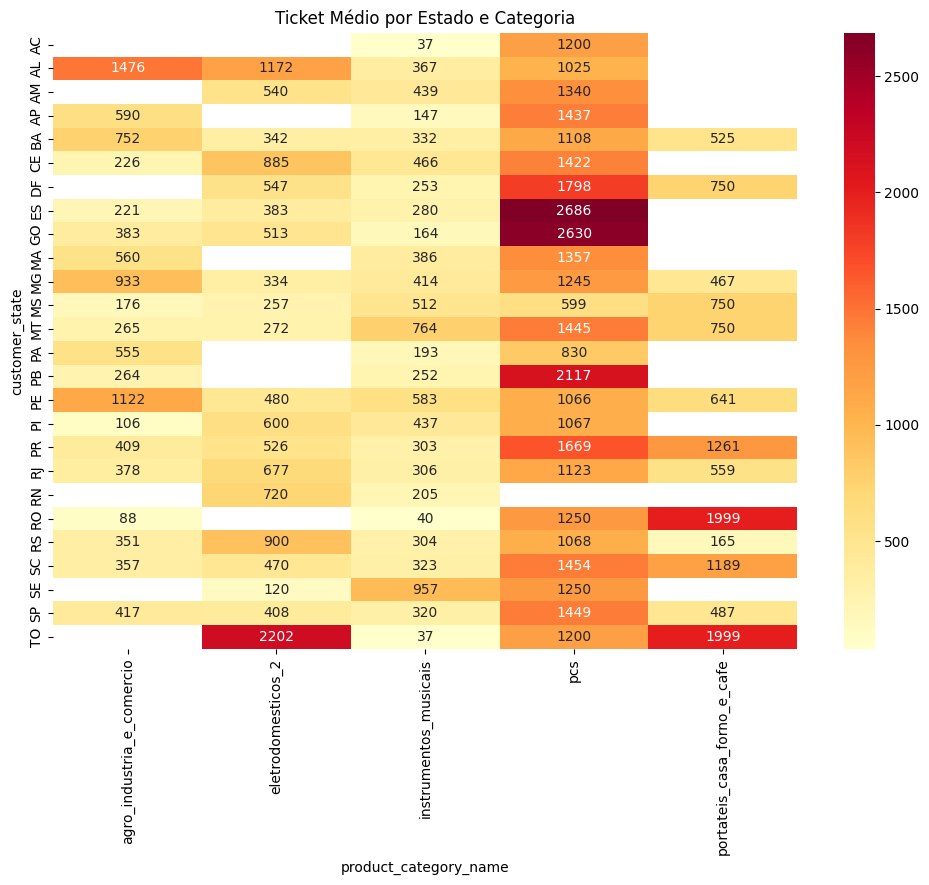

In [ ]:
top5_categorias = (
    ticket_categoria
    .head(5)
    .reset_index()[
        "product_category_name"
    ]
)

heatmap_ticket = (
    df_olist_filtrado[
        df_olist_filtrado[
            "product_category_name"
        ].isin(top5_categorias)
    ]
    .groupby(
        [
            "customer_state",
            "product_category_name"
        ]
    )
    .agg(
        Receita=("price", "sum"),
        Pedidos=("order_id", "nunique")
    )
)

heatmap_ticket["Ticket_Medio"] = (
    heatmap_ticket["Receita"] /
    heatmap_ticket["Pedidos"]
)

heatmap_ticket = (
    heatmap_ticket["Ticket_Medio"]
    .unstack()
)

plt.figure(figsize=(12,8))

sns.heatmap(
    heatmap_ticket,
    cmap="YlOrRd",
    annot=True,
    fmt=".0f"
)

plt.title(
    "Ticket Médio por Estado e Categoria"
)

plt.show()

## Clientes

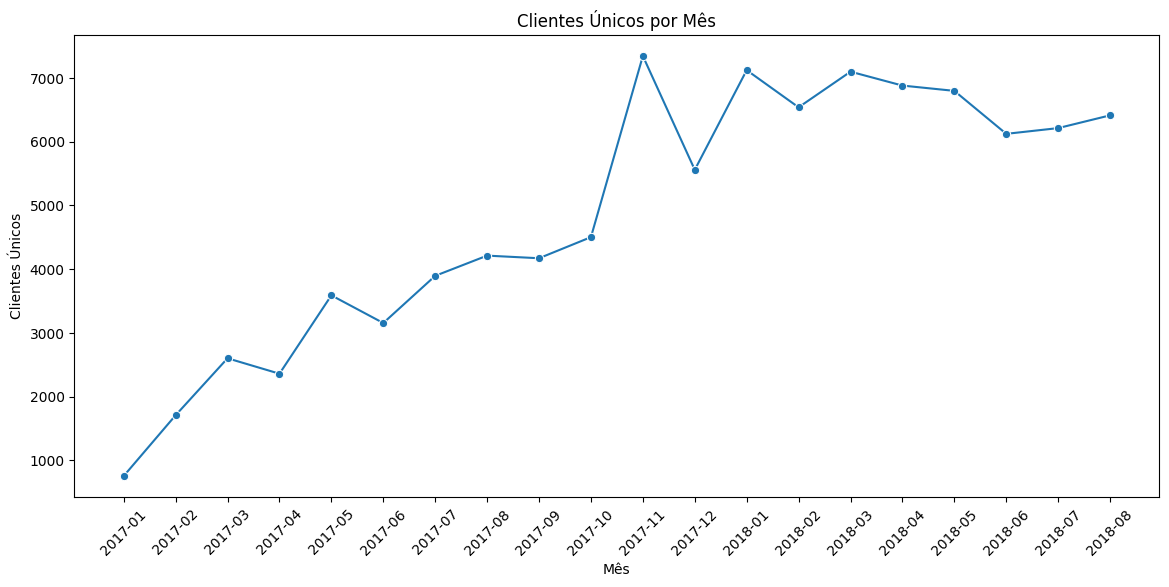

In [ ]:
clientes_mes = (
    df_olist_filtrado
    .groupby("ano_mes")["customer_unique_id"]
    .nunique()
    .reset_index()
)

clientes_mes.columns = [
    "Mês",
    "Clientes Únicos"
]

plt.figure(figsize=(14,6))

sns.lineplot(
    data=clientes_mes,
    x="Mês",
    y="Clientes Únicos",
    marker="o"
)

plt.title("Clientes Únicos por Mês")
plt.xticks(rotation=45)

plt.show()

Total de clientes únicos: 95,121
Clientes com apenas 1 compra: 92,221 (96.95%)
Clientes com recompra: 2,900 (3.05%)


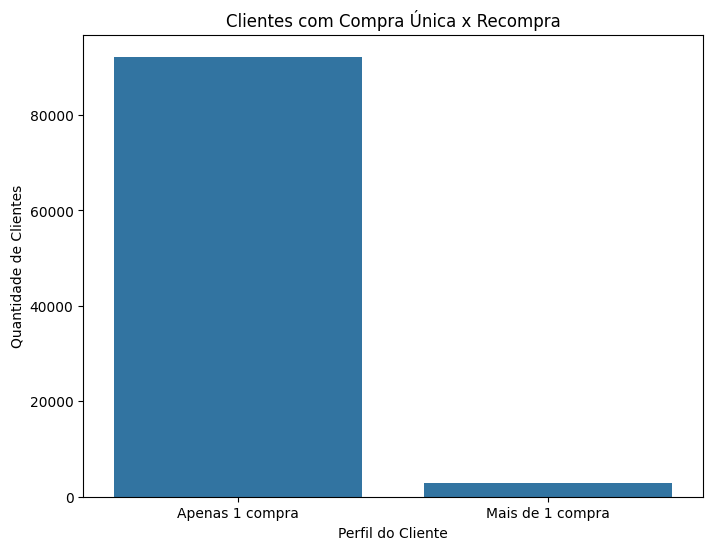

In [ ]:
# Quantidade de pedidos por cliente único

clientes_pedidos = (
    df_olist_filtrado
    .groupby("customer_unique_id")
    ["order_id"]
    .nunique()
    .reset_index()
)

clientes_pedidos.columns = [
    "Cliente Único",
    "Quantidade de Pedidos"
]

clientes_pedidos.head()

# Métricas de recompra

total_clientes = clientes_pedidos["Cliente Único"].nunique()

clientes_uma_compra = (
    clientes_pedidos["Quantidade de Pedidos"] == 1
).sum()

clientes_recompra = (
    clientes_pedidos["Quantidade de Pedidos"] > 1
).sum()

percentual_uma_compra = clientes_uma_compra / total_clientes * 100

percentual_recompra = clientes_recompra / total_clientes * 100

print(f"Total de clientes únicos: {total_clientes:,}")
print(f"Clientes com apenas 1 compra: {clientes_uma_compra:,} ({percentual_uma_compra:.2f}%)")
print(f"Clientes com recompra: {clientes_recompra:,} ({percentual_recompra:.2f}%)")

# Gráfico recompra x compra única

recompra_resumo = pd.DataFrame({
    "Perfil do Cliente": [
        "Apenas 1 compra",
        "Mais de 1 compra"
    ],
    "Quantidade de Clientes": [
        clientes_uma_compra,
        clientes_recompra
    ]
})

plt.figure(figsize=(8,6))

sns.barplot(
    data=recompra_resumo,
    x="Perfil do Cliente",
    y="Quantidade de Clientes"
)

plt.title("Clientes com Compra Única x Recompra")
plt.xlabel("Perfil do Cliente")
plt.ylabel("Quantidade de Clientes")
plt.show()

In [ ]:
# Quantidade de pedidos por cliente

clientes = (
    df_olist_filtrado
    .groupby("customer_unique_id")
    .agg(
        pedidos=("order_id", "nunique"),
        satisfacao_media=("review_score", "mean")
    )
    .reset_index()
)

clientes["Recompra"] = np.where(
    clientes["pedidos"] > 1,
    "Sim",
    "Não"
)

clientes.groupby("Recompra").agg(
    Clientes=("customer_unique_id", "count"),
    Pedidos_Medios=("pedidos", "mean"),
    Satisfacao_Media=("satisfacao_media", "mean")
)

,Clientes,Pedidos_Medios,Satisfacao_Media
Recompra,,,
Não,92221,1.000000,4.102375
Sim,2900,2.114483,4.144841


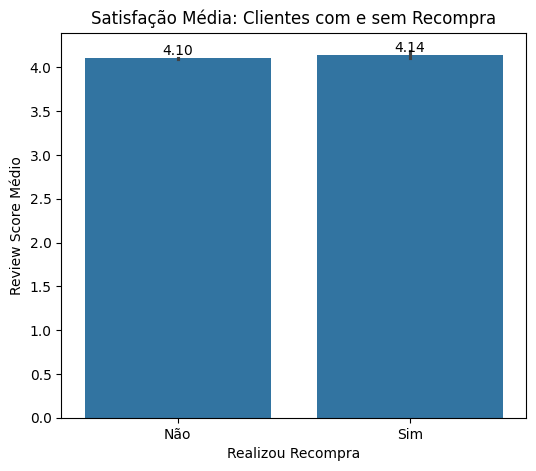

In [ ]:
plt.figure(figsize=(6,5))

ax = sns.barplot(
    data=clientes,
    x="Recompra",
    y="satisfacao_media",
    estimator=np.mean
)

for p in ax.patches:

    valor = p.get_height()

    ax.annotate(
        f"{valor:.2f}",
        (
            p.get_x() + p.get_width()/2,
            valor
        ),
        ha="center",
        va="bottom"
    )

plt.title("Satisfação Média: Clientes com e sem Recompra")
plt.xlabel("Realizou Recompra")
plt.ylabel("Review Score Médio")

plt.show()

## Frete

In [ ]:
orders_reviews_frete = (
    order_items
    .groupby("order_id")["freight_value"]
    .sum()
    .reset_index()
    .merge(
        order_reviews[["order_id", "review_score"]],
        on="order_id",
        how="inner"
    )
)

orders_reviews_frete.head()

,order_id,freight_value,review_score
0,00010242fe8c5a6d1ba2dd792cb16214,13.29,5
1,00018f77f2f0320c557190d7a144bdd3,19.93,4
2,000229ec398224ef6ca0657da4fc703e,17.87,5
3,00024acbcdf0a6daa1e931b038114c75,12.79,4
4,00042b26cf59d7ce69dfabb4e55b4fd9,18.14,5


In [ ]:
# Frete médio por nota de avaliação
frete_por_nota = (
    orders_reviews_frete
    .groupby("review_score")["freight_value"]
    .mean()
    .reset_index()
)

frete_por_nota

,review_score,freight_value
0,1,27.745622
1,2,26.266413
2,3,23.523808
3,4,22.367984
4,5,21.713246


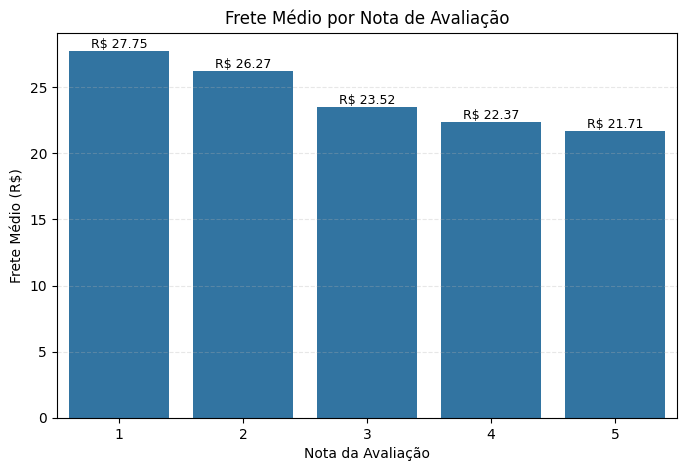

In [ ]:
plt.figure(figsize=(8,5))

ax = sns.barplot(
    data=frete_por_nota,
    x="review_score",
    y="freight_value"
)

for p in ax.patches:
    ax.annotate(
        f'R$ {p.get_height():.2f}',
        (p.get_x() + p.get_width()/2, p.get_height()),
        ha='center',
        va='bottom',
        fontsize=9
    )

plt.title("Frete Médio por Nota de Avaliação")
plt.xlabel("Nota da Avaliação")
plt.ylabel("Frete Médio (R$)")
plt.grid(axis="y", linestyle="--", alpha=0.3)

plt.show()

In [ ]:
correlacao = (
    orders_reviews_frete["freight_value"]
    .corr(
        orders_reviews_frete["review_score"]
    )
)

print(
    f"Correlação entre frete e avaliação: {correlacao:.3f}"
)

Correlação entre frete e avaliação: -0.089


In [ ]:
orders_reviews_frete["faixa_frete"] = pd.qcut(
    orders_reviews_frete["freight_value"],
    q=4,
    labels=[
        "Frete Baixo",
        "Frete Médio",
        "Frete Alto",
        "Frete Muito Alto"
    ]
)

impacto_frete = (
    orders_reviews_frete
    .groupby(
        "faixa_frete",
        observed=False
    )["review_score"]
    .mean()
    .reset_index()

)

impacto_frete

,faixa_frete,review_score
0,Frete Baixo,4.262316
1,Frete Médio,4.138681
2,Frete Alto,4.124350
3,Frete Muito Alto,3.893011


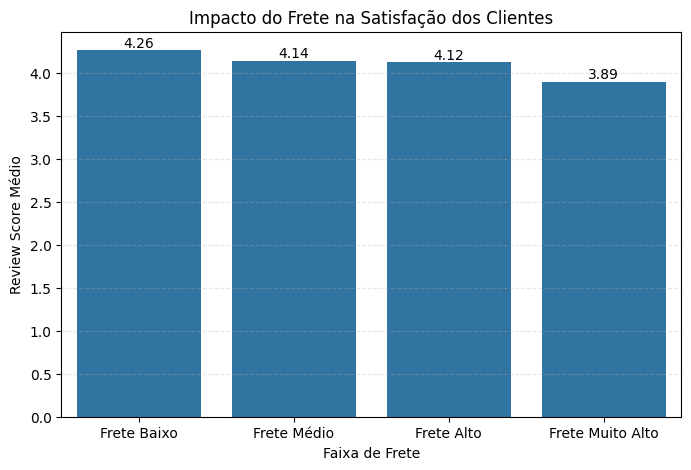

In [ ]:
plt.figure(figsize=(8,5))

ax = sns.barplot(
    data=impacto_frete,
    x="faixa_frete",
    y="review_score"
)

for p in ax.patches:
    ax.annotate(
        f'{p.get_height():.2f}',
        (p.get_x() + p.get_width()/2, p.get_height()),
        ha='center',
        va='bottom'
    )

plt.title("Impacto do Frete na Satisfação dos Clientes")
plt.xlabel("Faixa de Frete")
plt.ylabel("Review Score Médio")
plt.grid(axis="y", linestyle="--", alpha=0.3)

plt.show()

Observou-se tendência de redução da satisfação dos clientes em pedidos com fretes mais elevados. O resultado sugere que custos logísticos impactam diretamente a percepção de valor da compra, reforçando a importância de otimizações de frete e subsídios em categorias estratégicas.

## Análise de vendas dos próximos meses

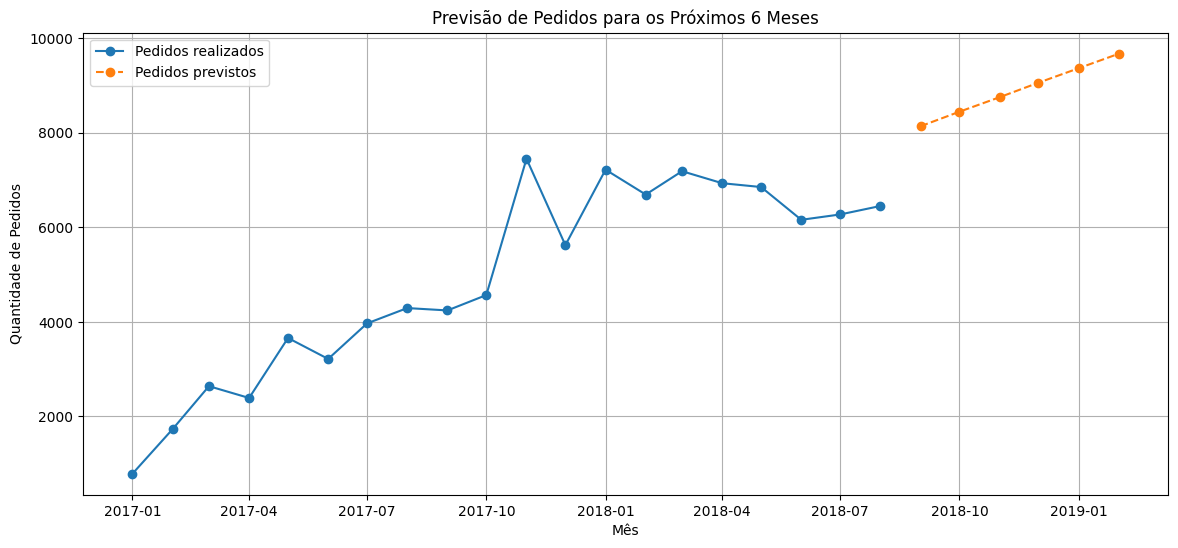

In [ ]:
# Preparar base mensal para previsão
vendas_mes = (
    df_olist_filtrado
    .groupby("ano_mes")
    .agg(
        pedidos=("order_id", "nunique"),
        receita=("price", "sum")
    )
    .reset_index()
)

vendas_mes["data"] = pd.to_datetime(vendas_mes["ano_mes"] + "-01")

vendas_mes = vendas_mes.sort_values("data")

vendas_mes

# Modelo simples de previsão com Regressão Linear

from sklearn.linear_model import LinearRegression
import numpy as np

vendas_mes["mes_numero"] = np.arange(len(vendas_mes))

X = vendas_mes[["mes_numero"]]
y = vendas_mes["pedidos"]

modelo = LinearRegression()
modelo.fit(X, y)

# prever próximos 6 meses
proximos_meses = pd.DataFrame({
    "mes_numero": np.arange(
        len(vendas_mes),
        len(vendas_mes) + 6
    )
})

previsao_pedidos = modelo.predict(proximos_meses)

datas_futuras = pd.date_range(
    start=vendas_mes["data"].max() + pd.DateOffset(months=1),
    periods=6,
    freq="MS"
)

previsao = pd.DataFrame({
    "data": datas_futuras,
    "pedidos_previstos": previsao_pedidos.round(0).astype(int)
})

previsao

# Gráfico da previsão

plt.figure(figsize=(14,6))

plt.plot(
    vendas_mes["data"],
    vendas_mes["pedidos"],
    marker="o",
    label="Pedidos realizados"
)

plt.plot(
    previsao["data"],
    previsao["pedidos_previstos"],
    marker="o",
    linestyle="--",
    label="Pedidos previstos"
)

plt.title("Previsão de Pedidos para os Próximos 6 Meses")
plt.xlabel("Mês")
plt.ylabel("Quantidade de Pedidos")
plt.legend()
plt.grid(True)
plt.show()

# Conclusões

A análise dos dados da Olist permitiu identificar importantes padrões de consumo no e-commerce brasileiro entre janeiro de 2017 e agosto de 2018. Para garantir maior consistência dos resultados, os dados de 2016 foram desconsiderados por representarem o início da operação, enquanto setembro de 2018 foi excluído por estar incompleto.

Observou-se uma forte concentração dos pedidos na região Sudeste, com destaque para o estado de São Paulo, que apresentou a maior participação no volume total de pedidos. Esse resultado é coerente com a maior população e atividade econômica do estado.

Entretanto, ao analisar a receita média por cliente, verifica-se que o volume de pedidos não necessariamente reflete a rentabilidade individual dos consumidores. Alguns estados apresentam menor participação no número de pedidos, mas geram maior receita média por cliente, indicando oportunidades de crescimento e estratégias comerciais mais direcionadas.

A análise também reforça a importância de avaliar indicadores relativos e não apenas volumes absolutos. Enquanto a participação dos pedidos demonstra a representatividade de cada estado na operação, a receita média por cliente permite identificar mercados com maior potencial de geração de valor.
